In [1]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from catboost import CatBoostRegressor

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)

train_df = pd.read_csv(r"/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

In [3]:
# Data types
print("\nSummary of data types:")
print(train_df.dtypes.to_string())


Summary of data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
H

In [4]:
#Handle missing values
categorical_columns = [col for col in train_df.columns if train_df[col].dtype == object]

print("\nMissing Values in categorical features before imputing:\n")
for col in train_df.columns:
    if train_df[col].isna().sum() != 0 and train_df[col].dtype == object:
        print("{} has {} missing values".format(col,train_df[col].isna().sum()))

train_df[categorical_columns] = train_df[categorical_columns].fillna('Missing')

print("\nMissing Values in numerical features before imputing:\n")
for col in train_df.columns:
    if train_df[col].isna().sum() != 0 and train_df[col].dtype != object:
        print("{} has {} missing values".format(col,train_df[col].isna().sum()))

for column in train_df.columns:
    if train_df[column].dtype == float or train_df[column].dtype == int:
        train_df[column] = train_df[column].fillna(0)

train_df[train_df.select_dtypes(include='float').columns] = train_df.select_dtypes(include='float').round().astype(int)

integer_columns = [col for col in train_df.columns if train_df[col].dtype != object]

integer_columns.remove("Id")

integer_columns_without_target = [col for col in integer_columns if col != "SalePrice"]



Missing Values in categorical features before imputing:

Alley has 1369 missing values
MasVnrType has 872 missing values
BsmtQual has 37 missing values
BsmtCond has 37 missing values
BsmtExposure has 38 missing values
BsmtFinType1 has 37 missing values
BsmtFinType2 has 38 missing values
Electrical has 1 missing values
FireplaceQu has 690 missing values
GarageType has 81 missing values
GarageFinish has 81 missing values
GarageQual has 81 missing values
GarageCond has 81 missing values
PoolQC has 1453 missing values
Fence has 1179 missing values
MiscFeature has 1406 missing values

Missing Values in numerical features before imputing:

LotFrontage has 259 missing values
MasVnrArea has 8 missing values
GarageYrBlt has 81 missing values


In [5]:
# Finding feature pairs with high correlation
train_df_coded = train_df.copy()

for i in categorical_columns:
    train_df_coded[i + '_coded'] = LabelEncoder().fit_transform(train_df_coded[i])

train_df_coded = train_df_coded.drop(categorical_columns, axis = 1)

train_df_coded_corr_matrix = train_df_coded.corr()

high_correlation_pairs = (train_df_coded_corr_matrix.abs() >= 0.6) & (train_df_coded_corr_matrix != 1)

upper_triangle_indices = zip(*np.triu_indices_from(train_df_coded_corr_matrix, k=1))

unique_pairs = [(train_df_coded_corr_matrix.index[i], 
                 train_df_coded_corr_matrix.columns[j], 
                 train_df_coded_corr_matrix.iloc[i, j]) for i, j in upper_triangle_indices if high_correlation_pairs.iloc[i, j]]

unique_pairs_df = pd.DataFrame(unique_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])

print("\nUnique Pairs with High Correlation:")
print(unique_pairs_df)

'''
It is observed from the correlation matrix that the sales price of a house is strongly correlated with the following features:
    1) OverallQual - Overall material and finish quality
    2) TotalBsmtSF - Total square feet of basement area
    3) 1stFlrSF - First Floor square feet
    4) GrLivArea - Above grade (ground) living area square feet
    5) GarageCars - Size of garage in car capacity
    6) GarageArea - Size of garage in square feet
    7) ExterQual - Exterior material quality
'''


Unique Pairs with High Correlation:
            Feature_1           Feature_2  Correlation
0          MSSubClass      BldgType_coded     0.746063
1         OverallQual          GarageCars     0.600671
2         OverallQual           SalePrice     0.790982
3         OverallQual     ExterQual_coded    -0.634319
4           YearBuilt    Foundation_coded     0.634842
5           YearBuilt      BsmtQual_coded    -0.608569
6          BsmtFinSF1        BsmtFullBath     0.649212
7          BsmtFinSF2  BsmtFinType2_coded    -0.706303
8         TotalBsmtSF            1stFlrSF     0.819530
9         TotalBsmtSF           SalePrice     0.613581
10           1stFlrSF           SalePrice     0.605852
11           2ndFlrSF           GrLivArea     0.687501
12           2ndFlrSF            HalfBath     0.609707
13           2ndFlrSF        TotRmsAbvGrd     0.616423
14          GrLivArea            FullBath     0.630012
15          GrLivArea        TotRmsAbvGrd     0.825489
16          GrLivArea       

'\nIt is observed from the correlation matrix that the sales price of a house is strongly correlated with the following features:\n    1) OverallQual - Overall material and finish quality\n    2) TotalBsmtSF - Total square feet of basement area\n    3) 1stFlrSF - First Floor square feet\n    4) GrLivArea - Above grade (ground) living area square feet\n    5) GarageCars - Size of garage in car capacity\n    6) GarageArea - Size of garage in square feet\n    7) ExterQual - Exterior material quality\n'

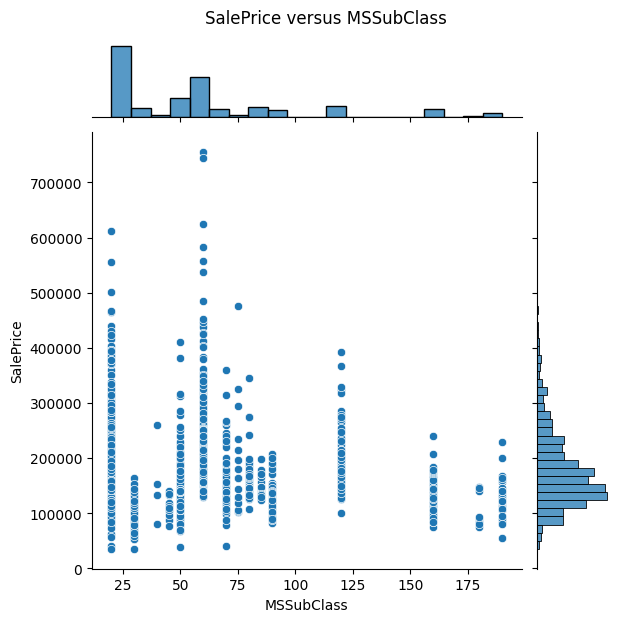

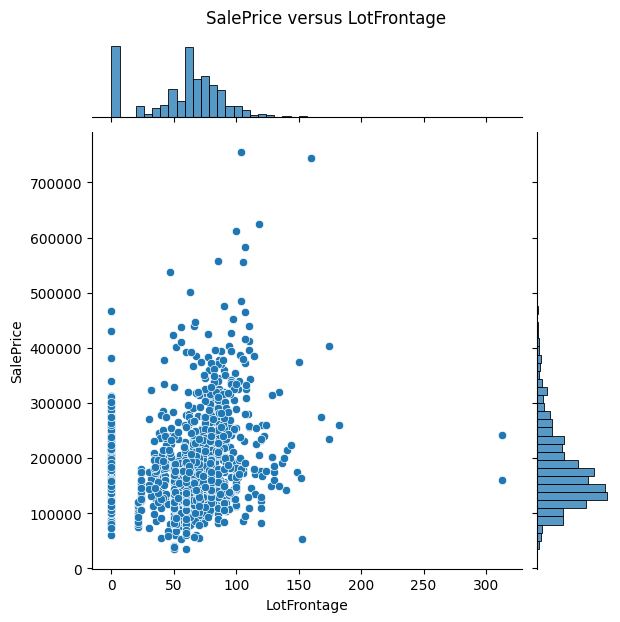

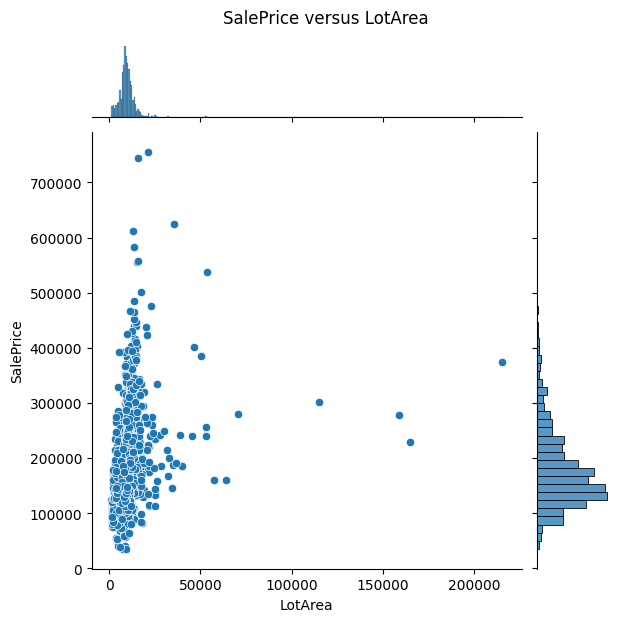

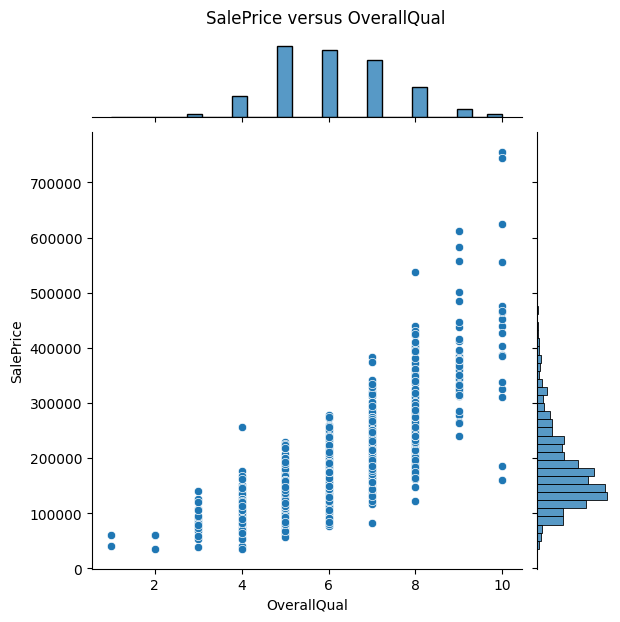

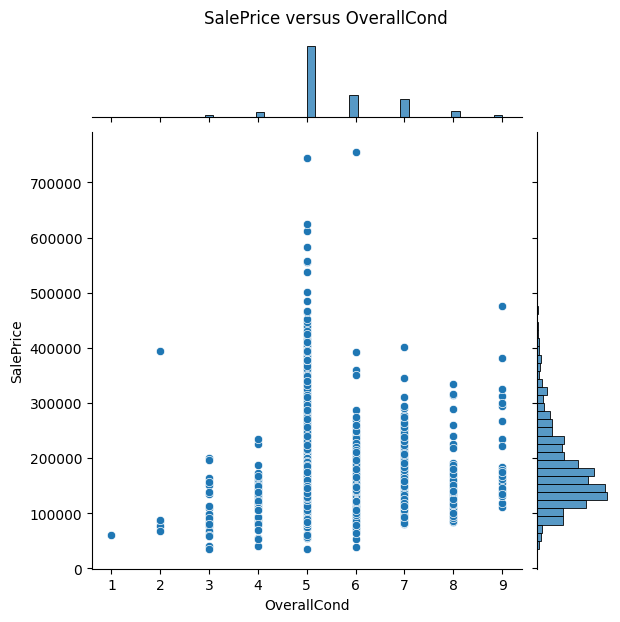

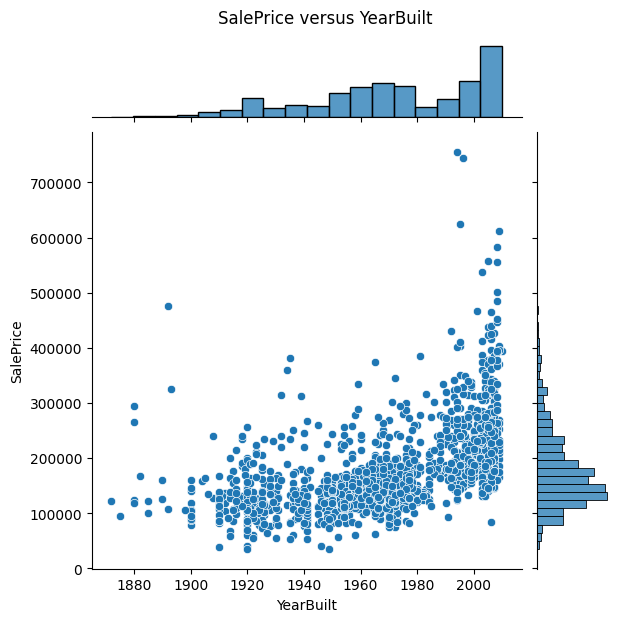

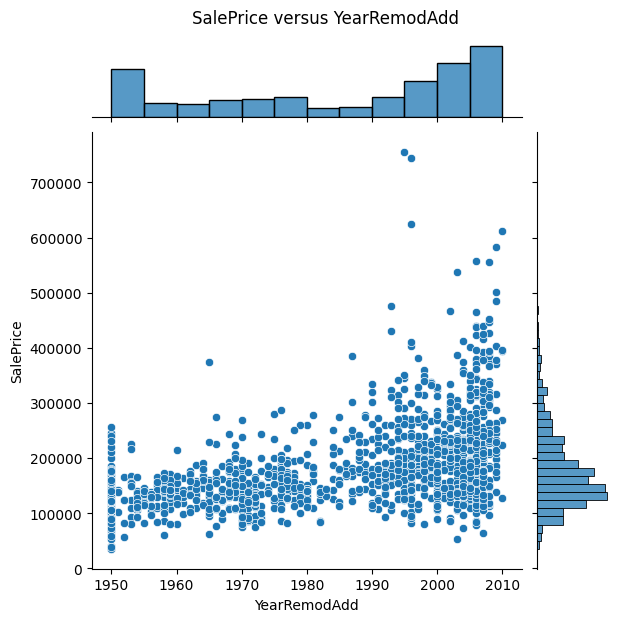

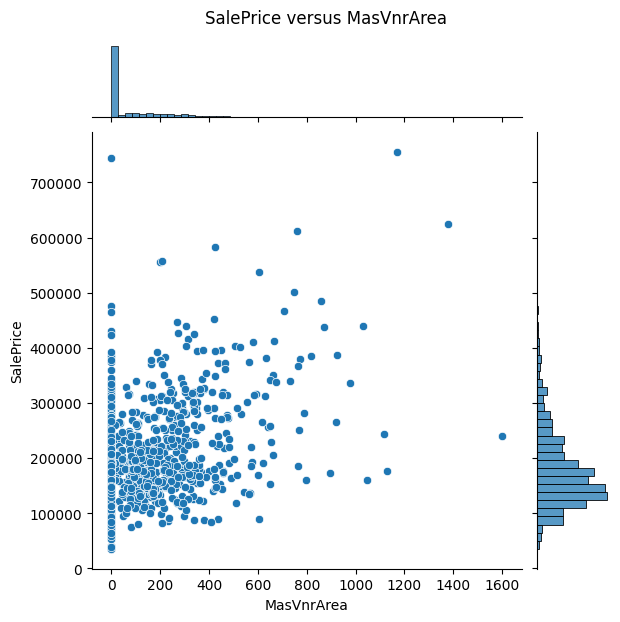

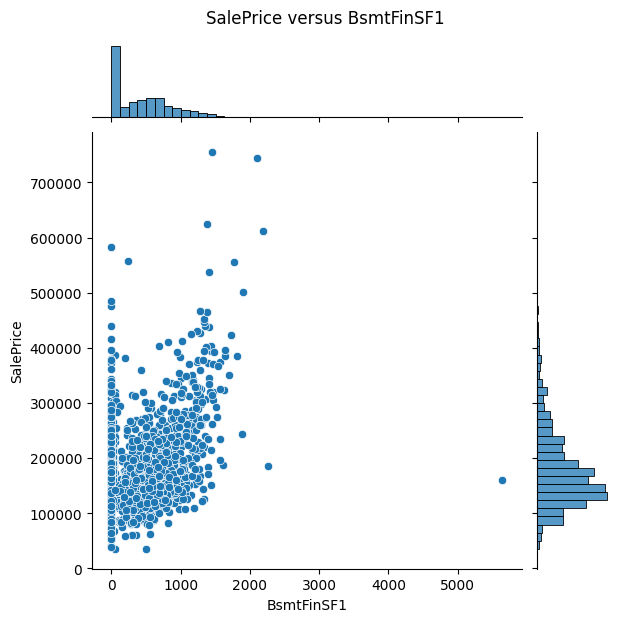

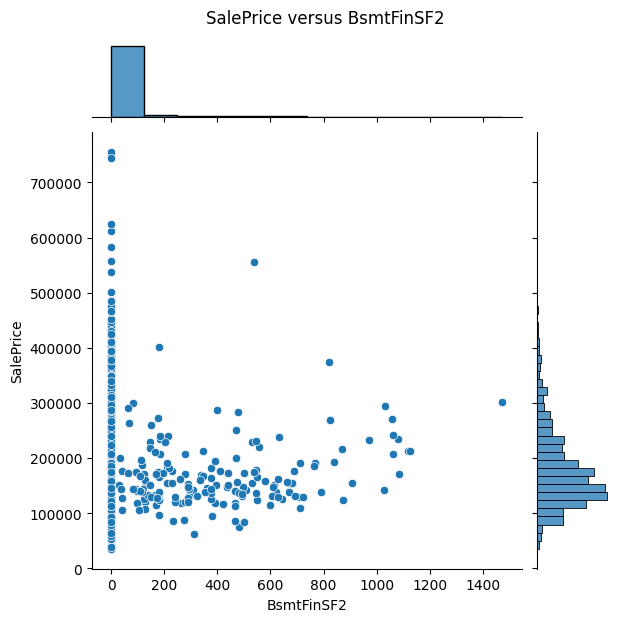

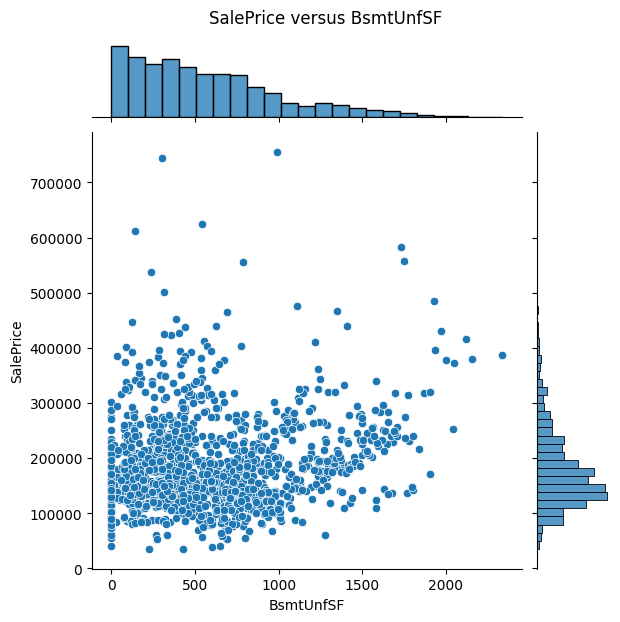

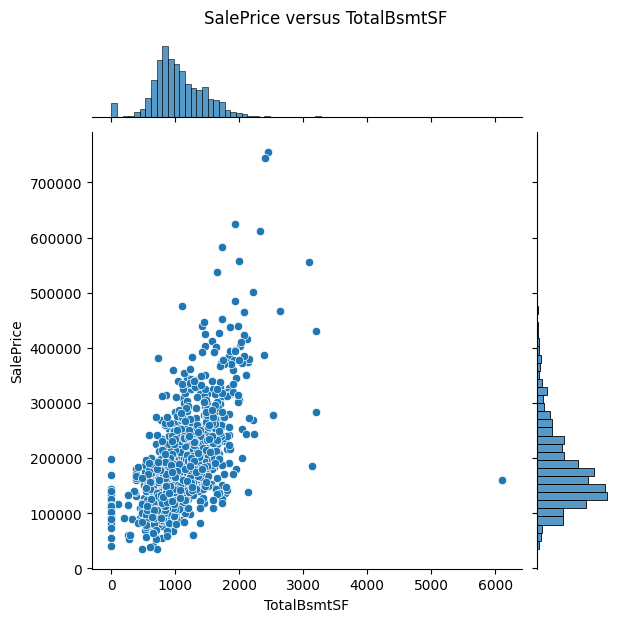

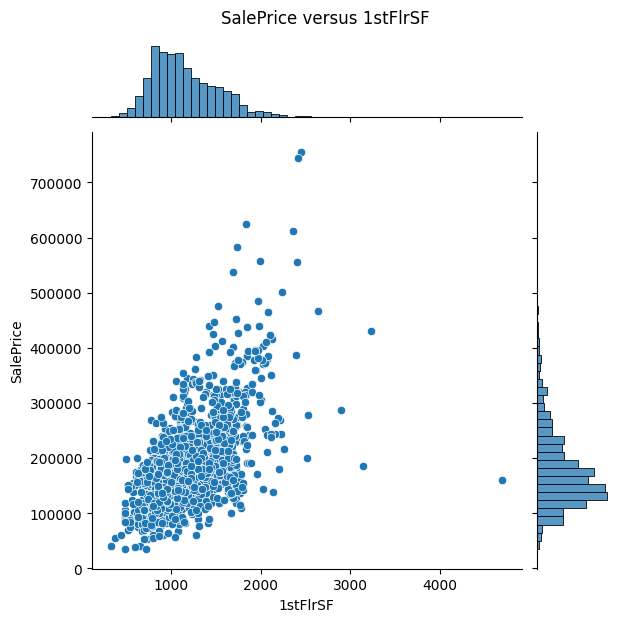

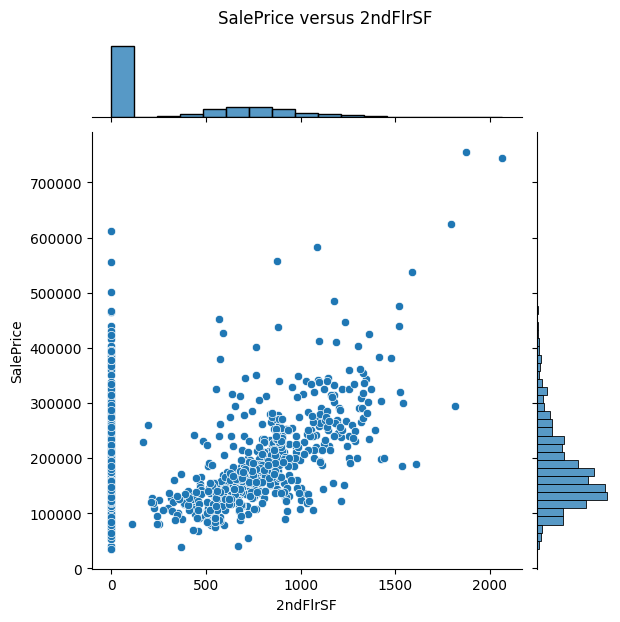

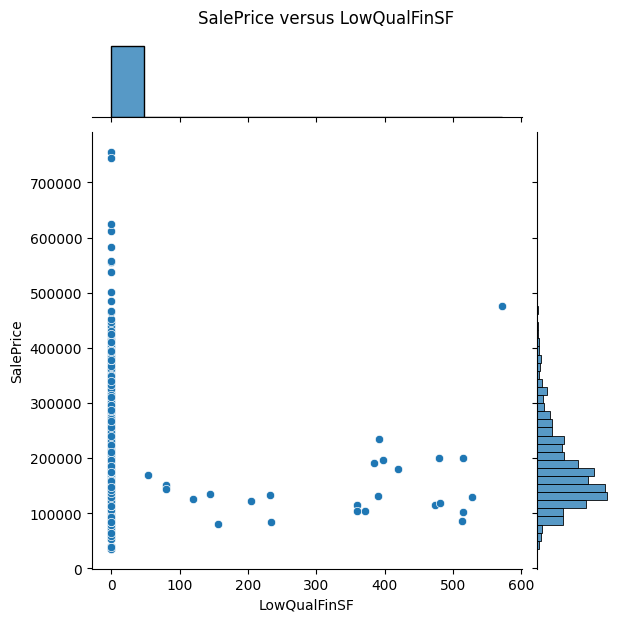

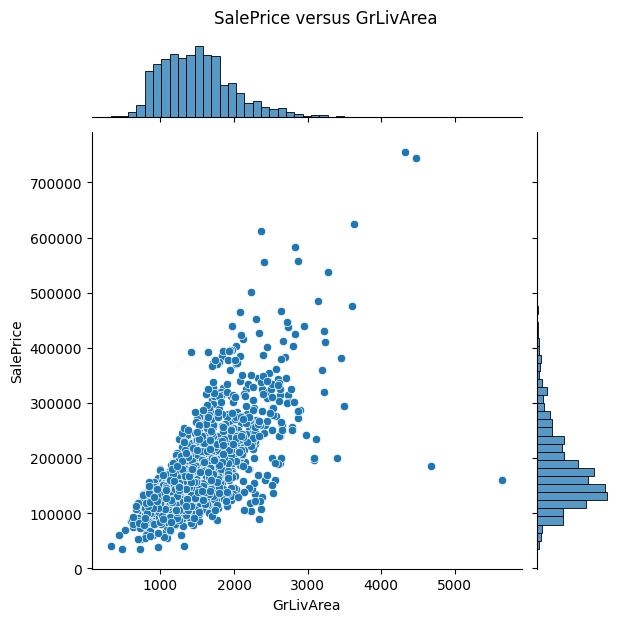

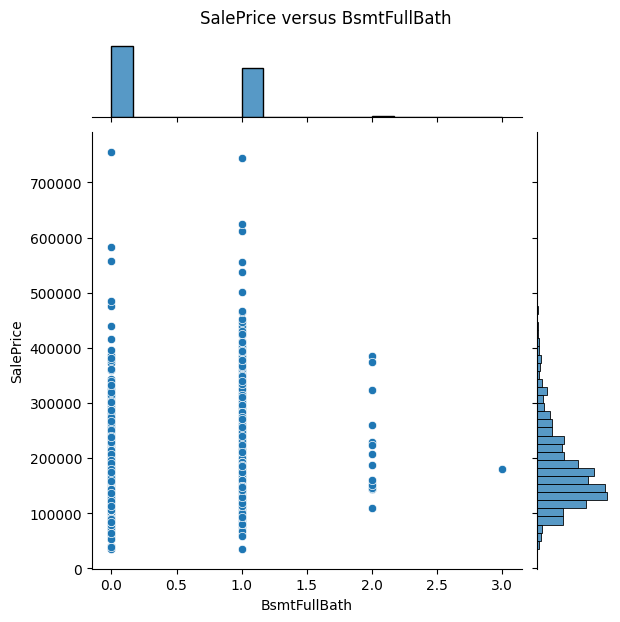

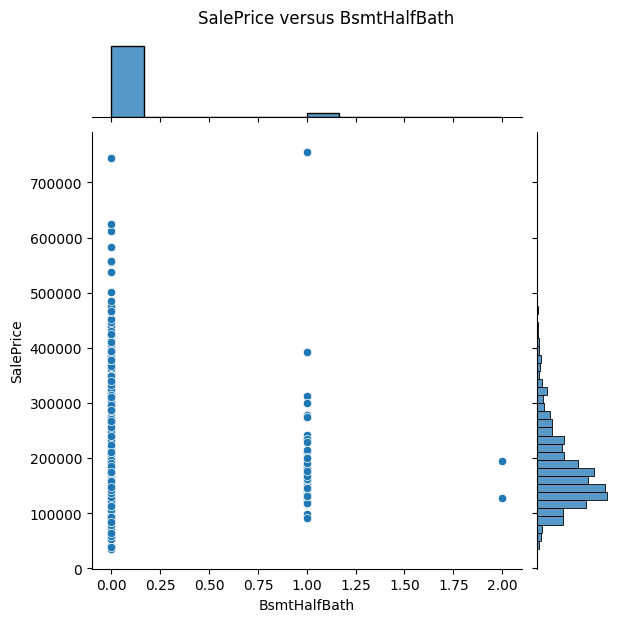

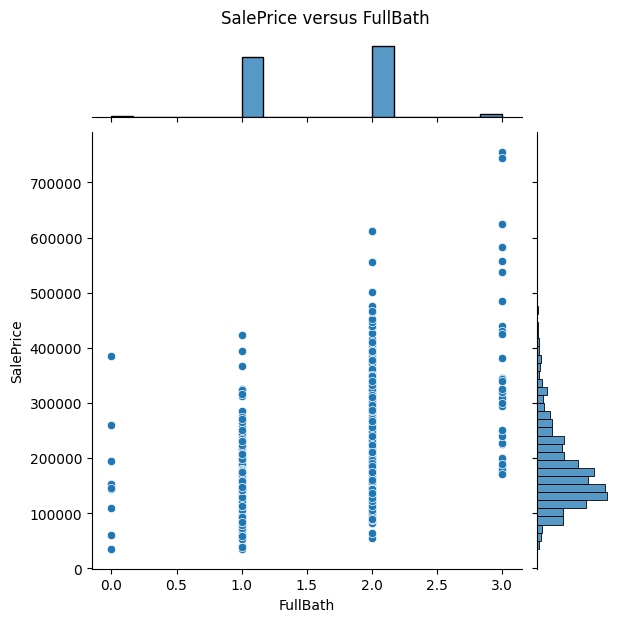

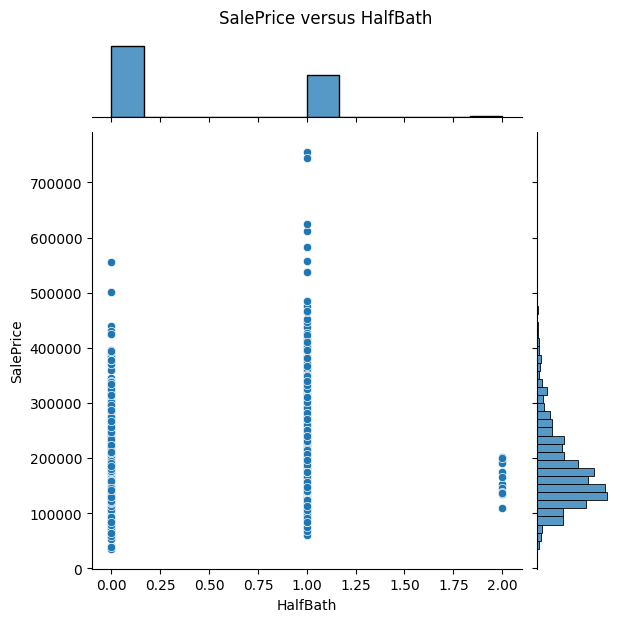

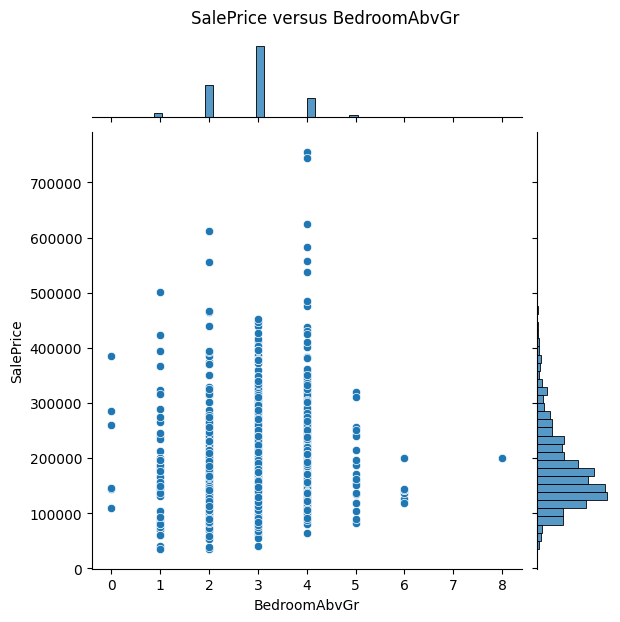

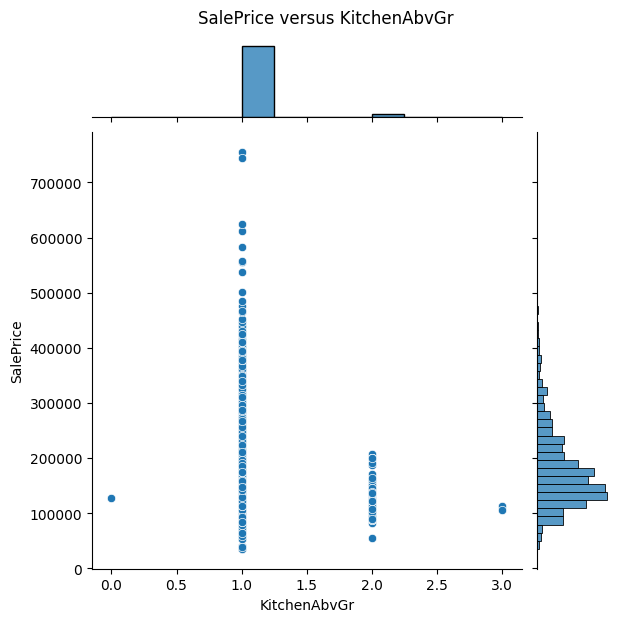

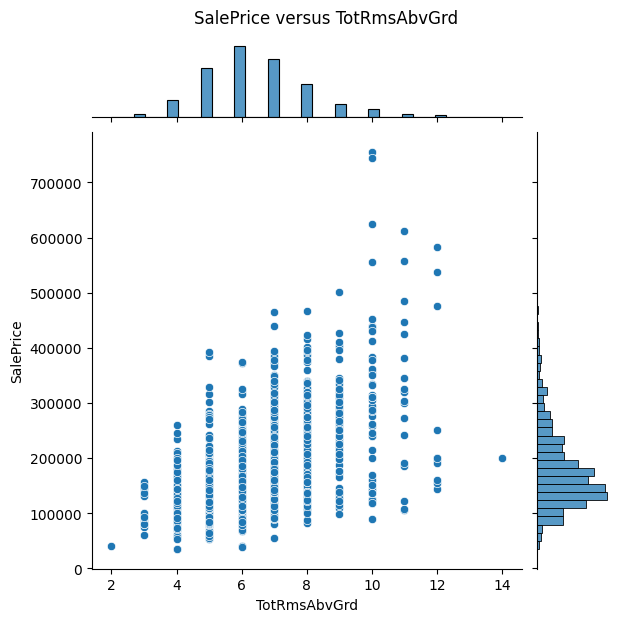

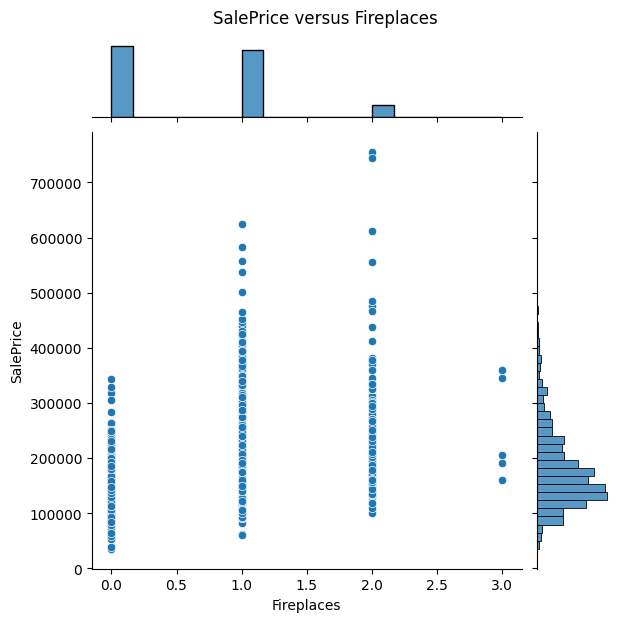

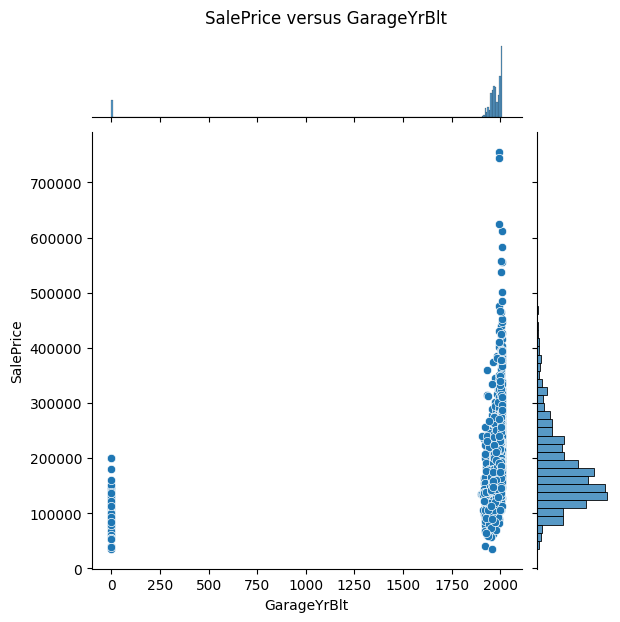

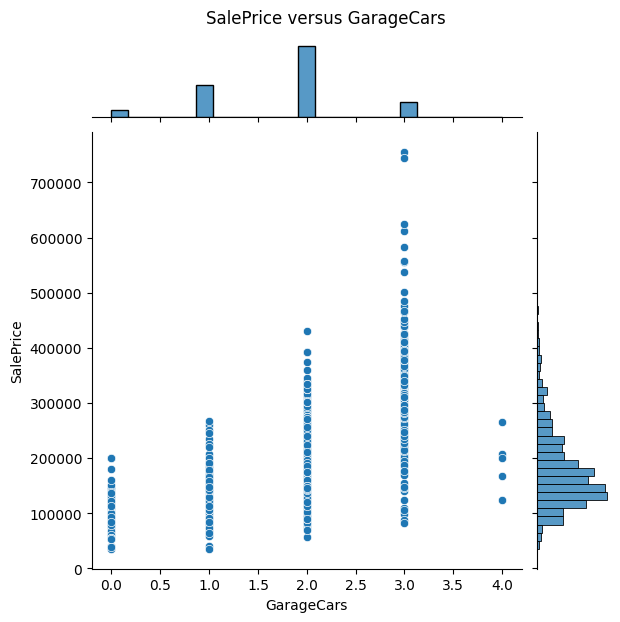

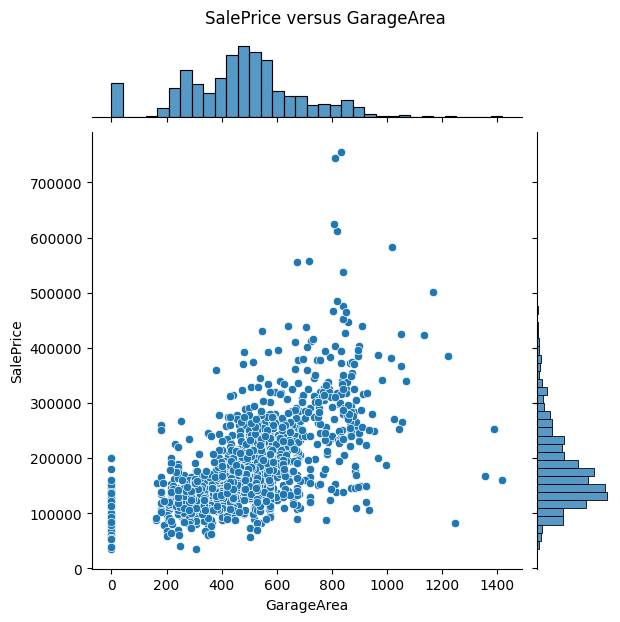

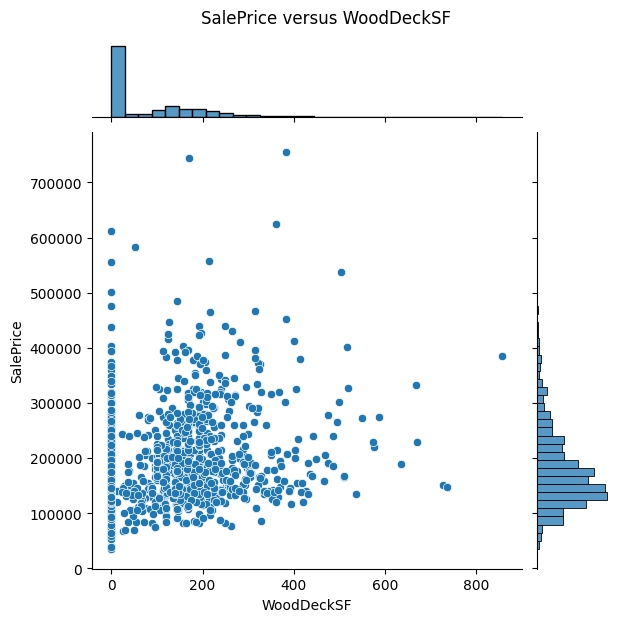

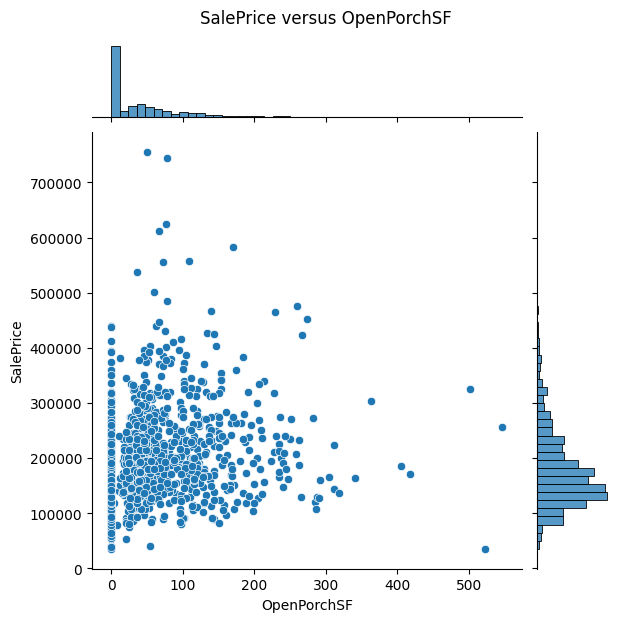

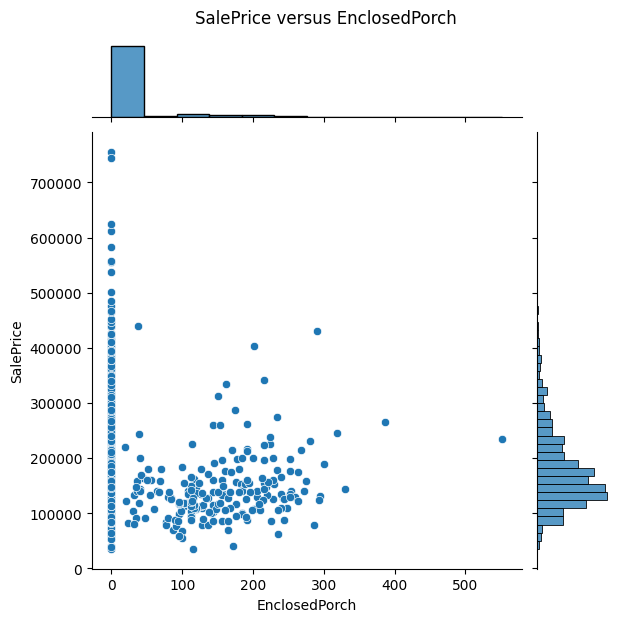

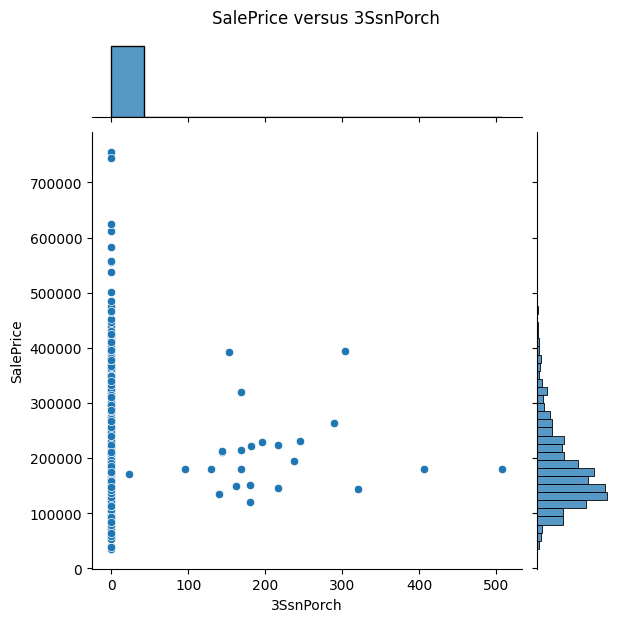

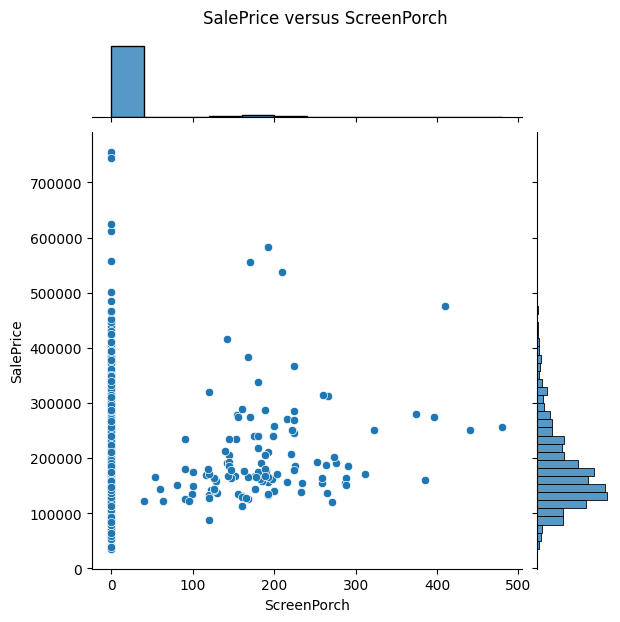

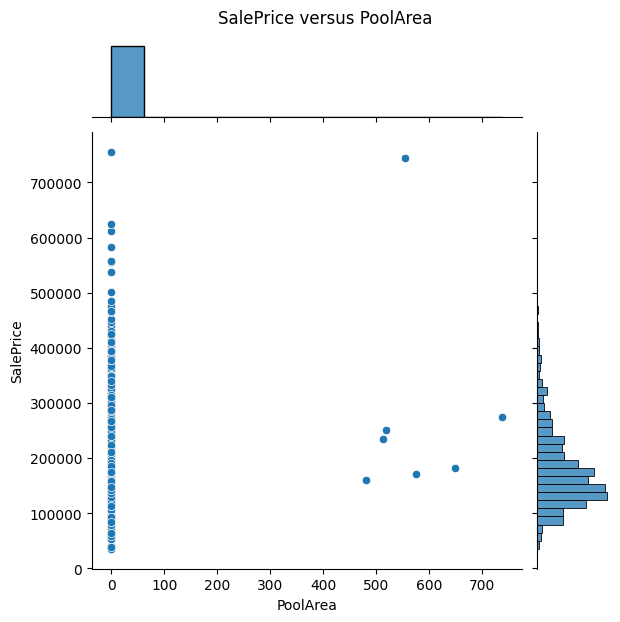

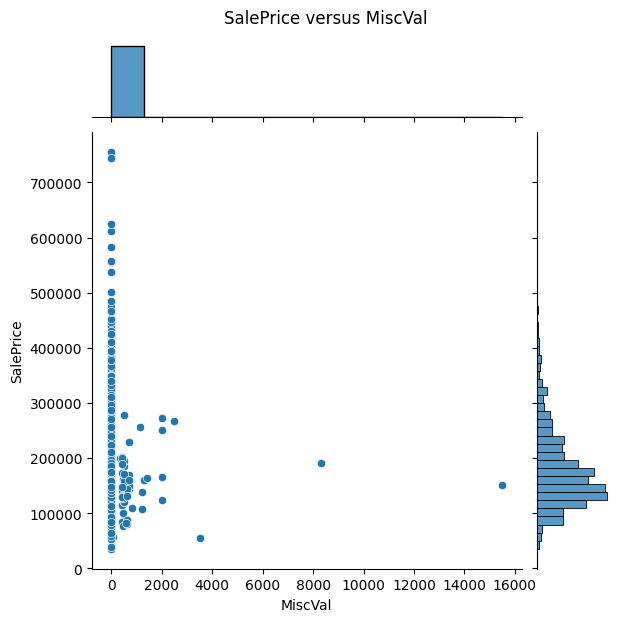

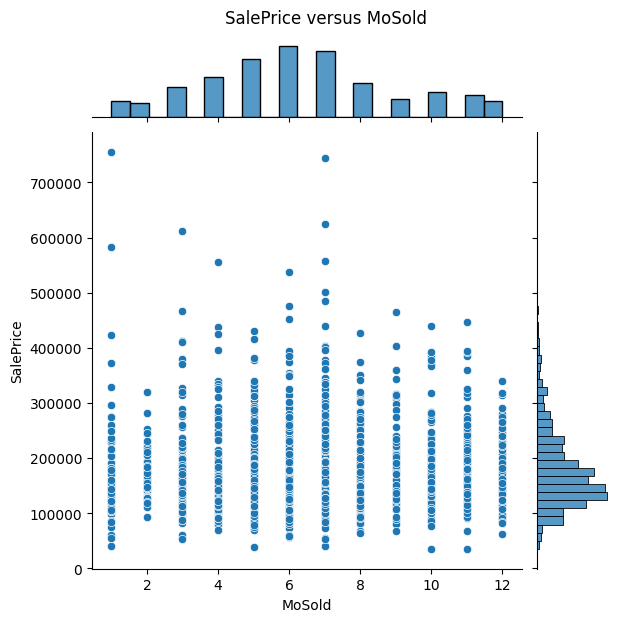

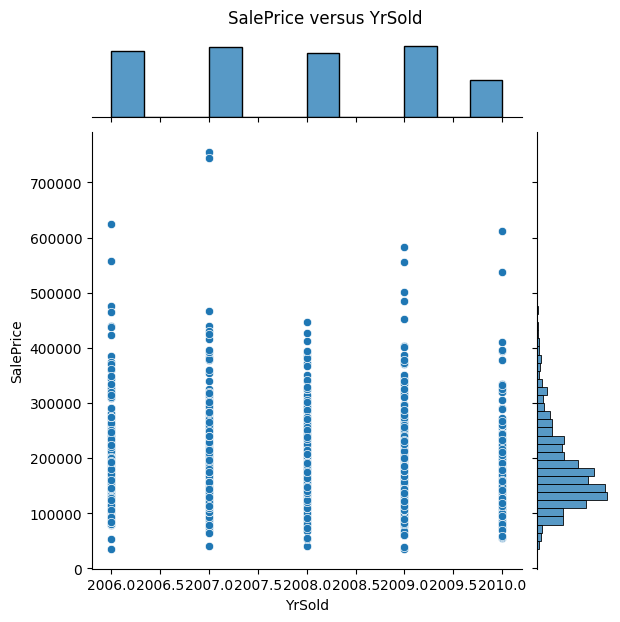

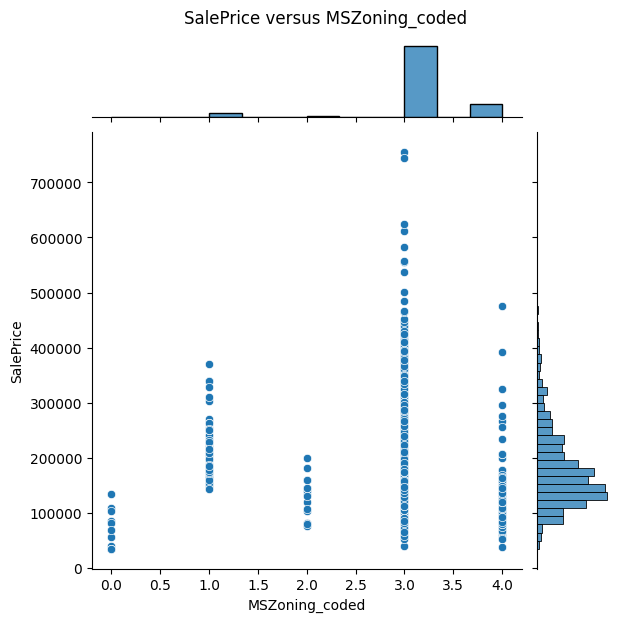

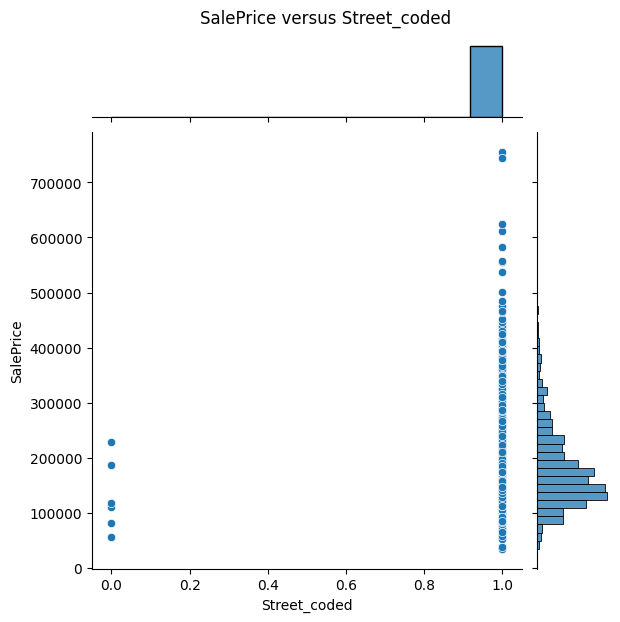

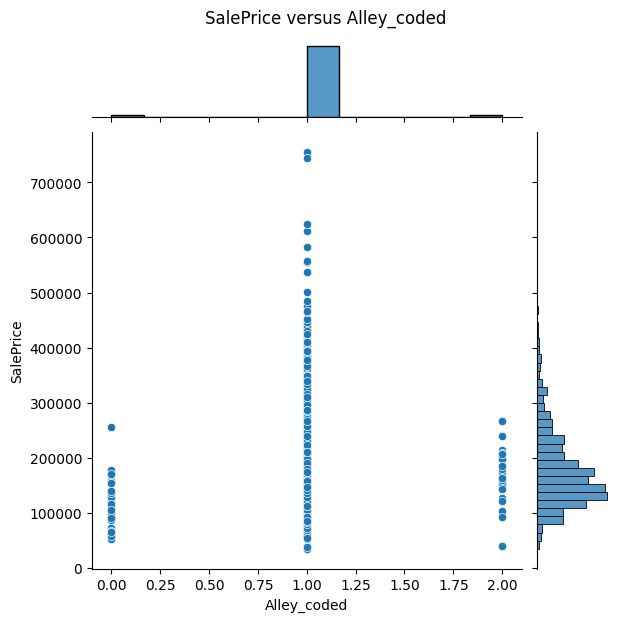

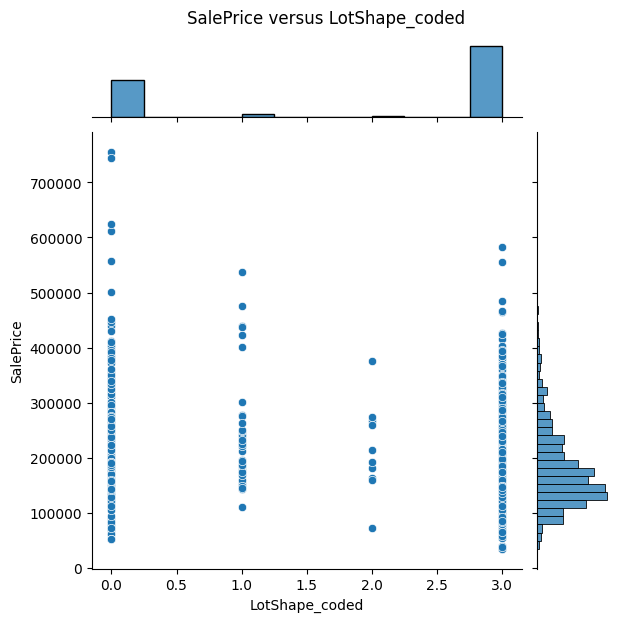

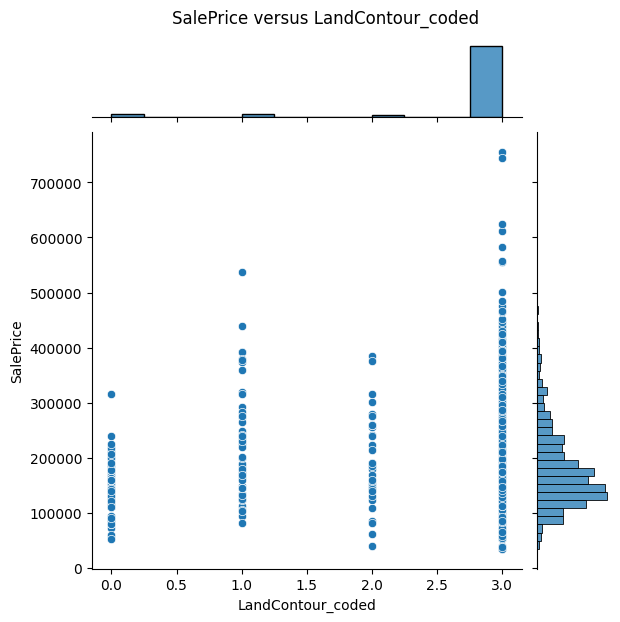

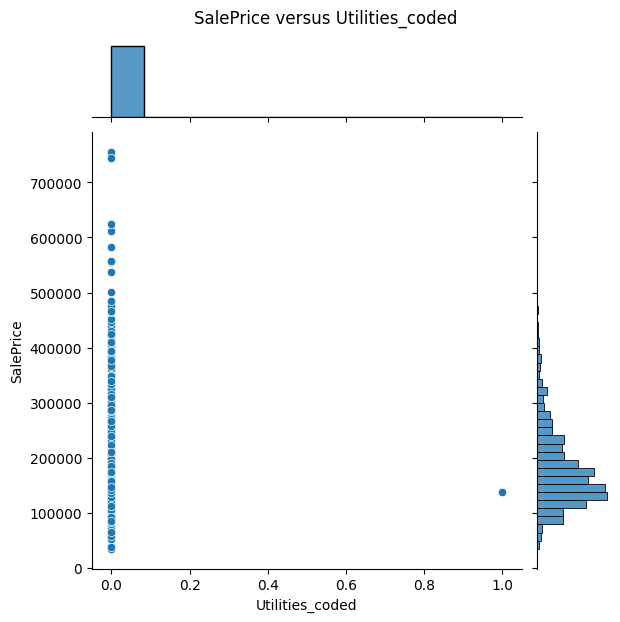

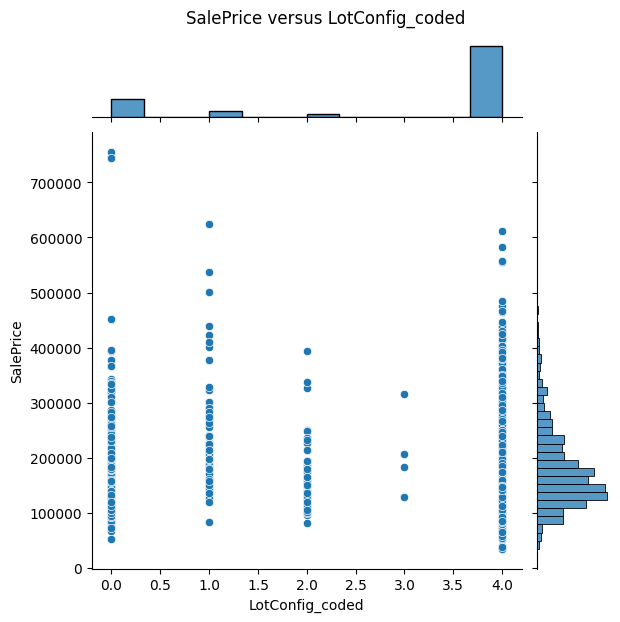

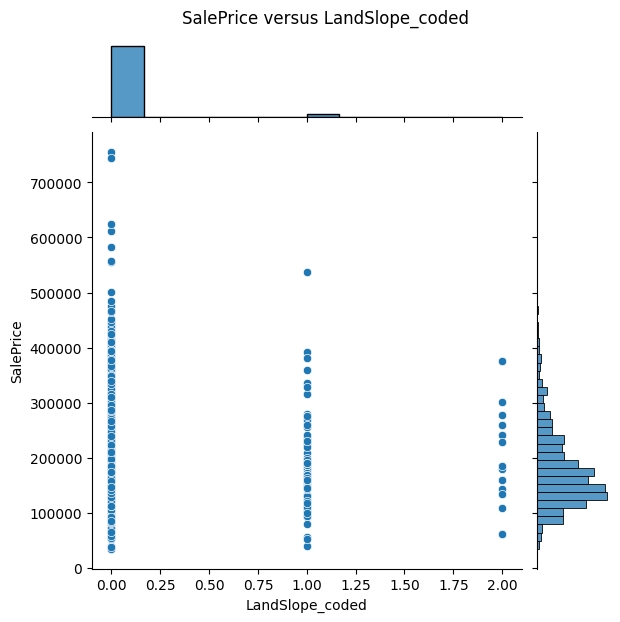

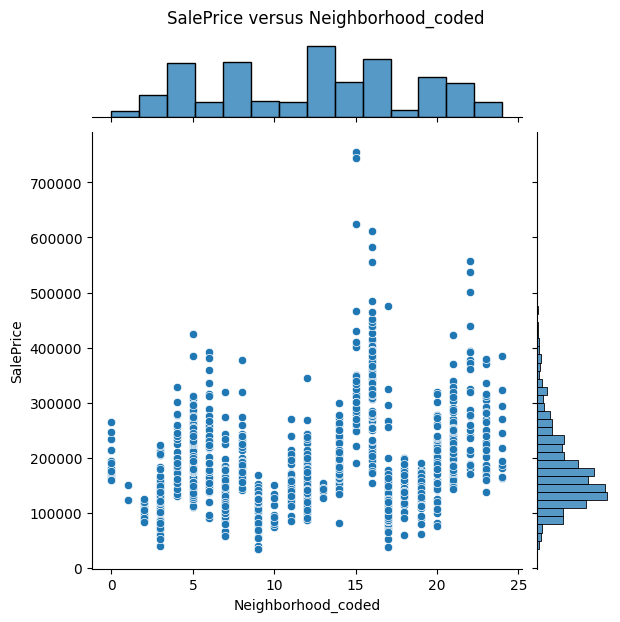

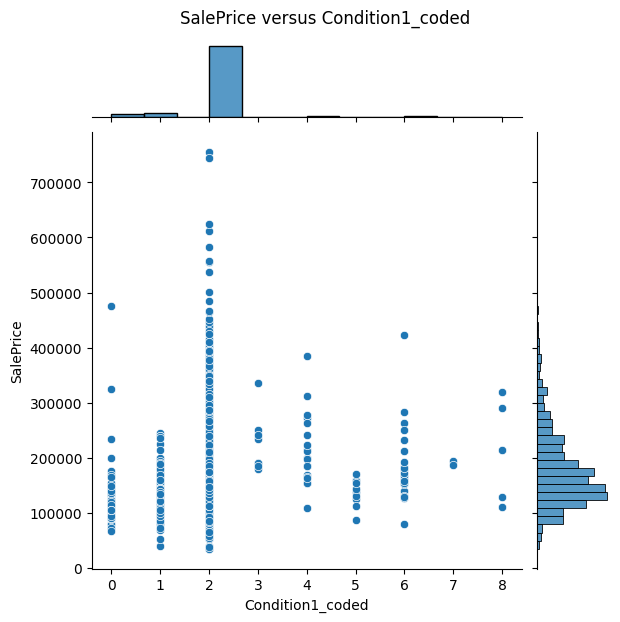

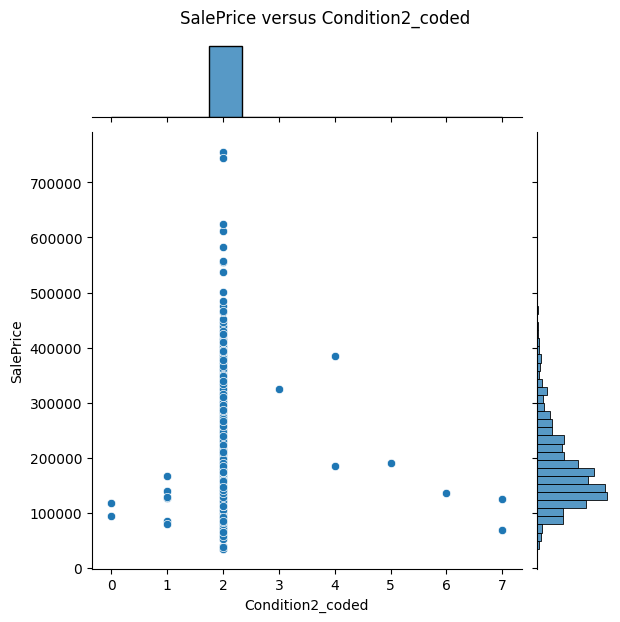

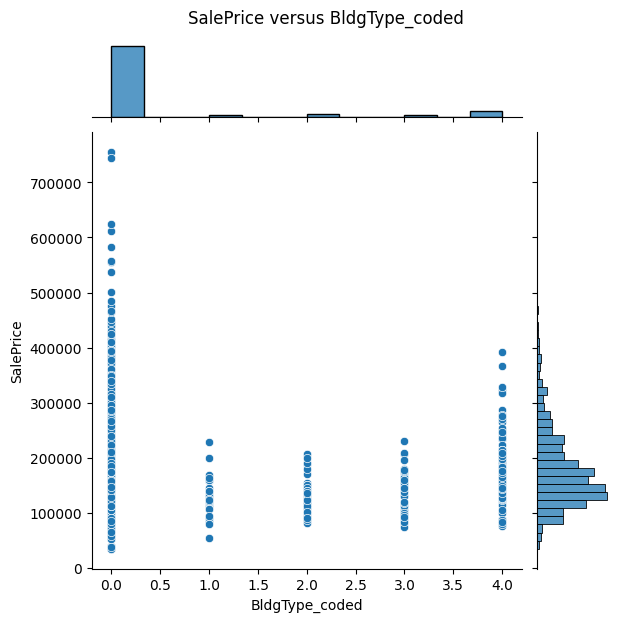

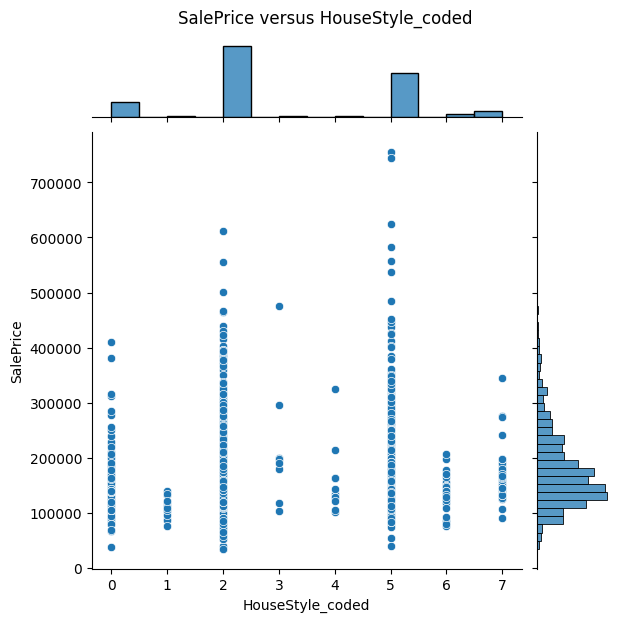

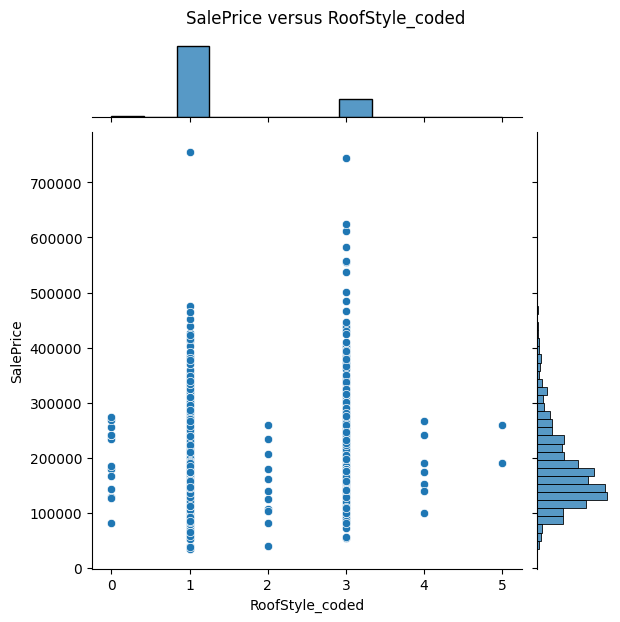

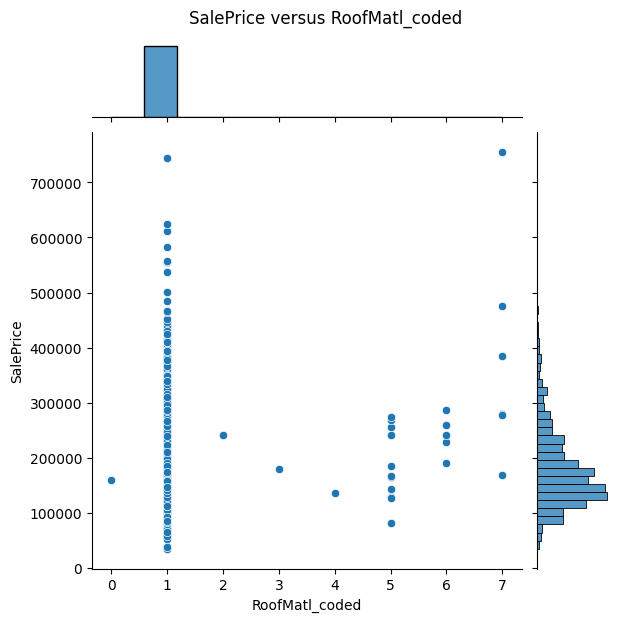

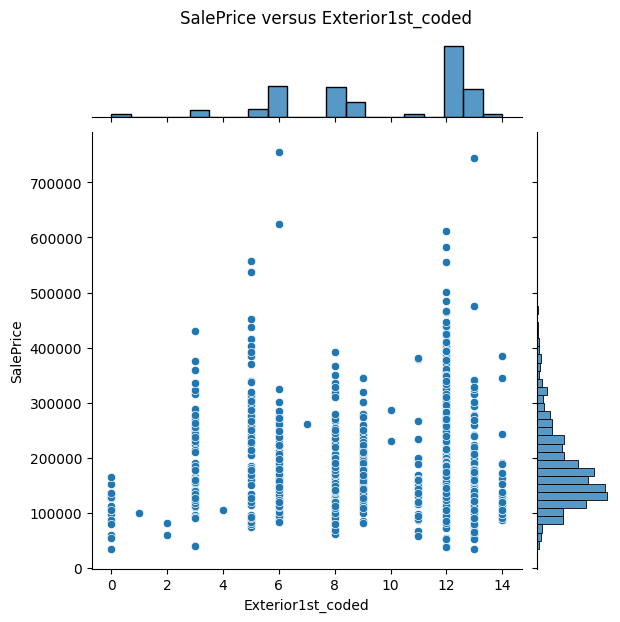

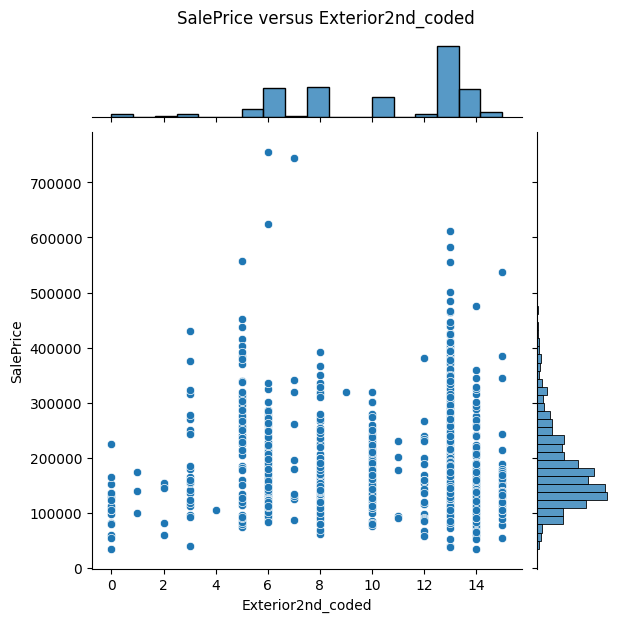

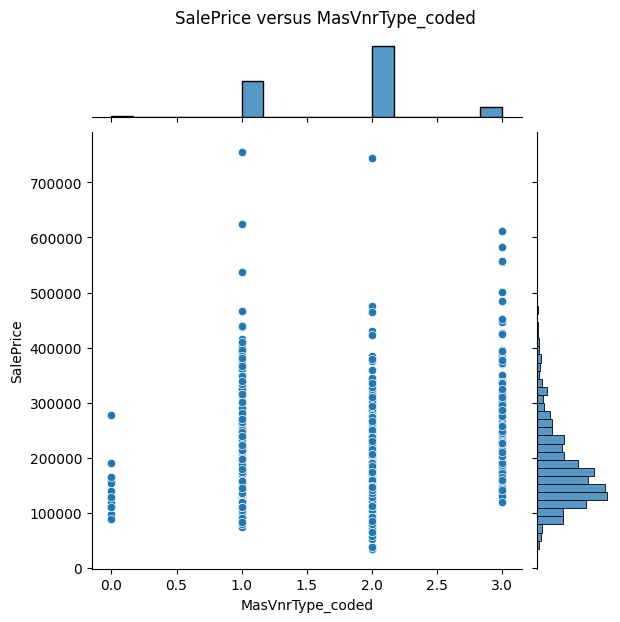

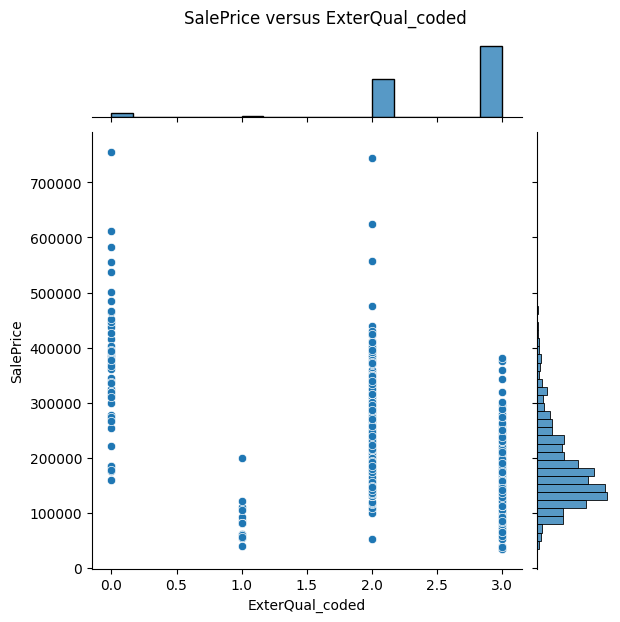

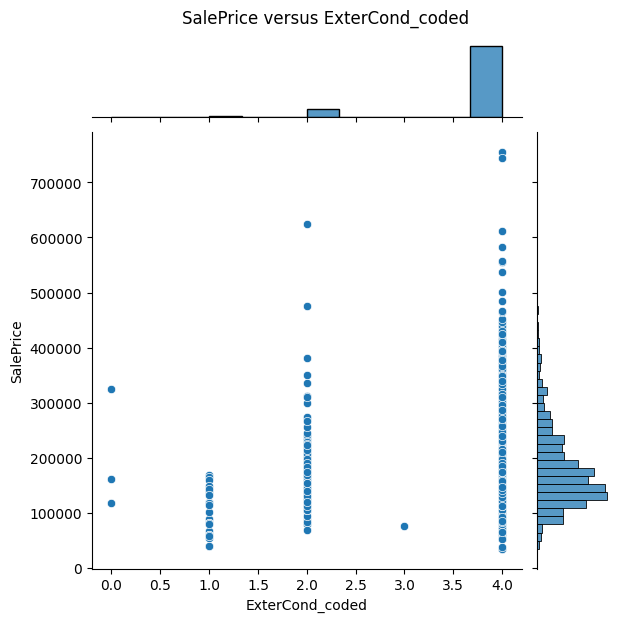

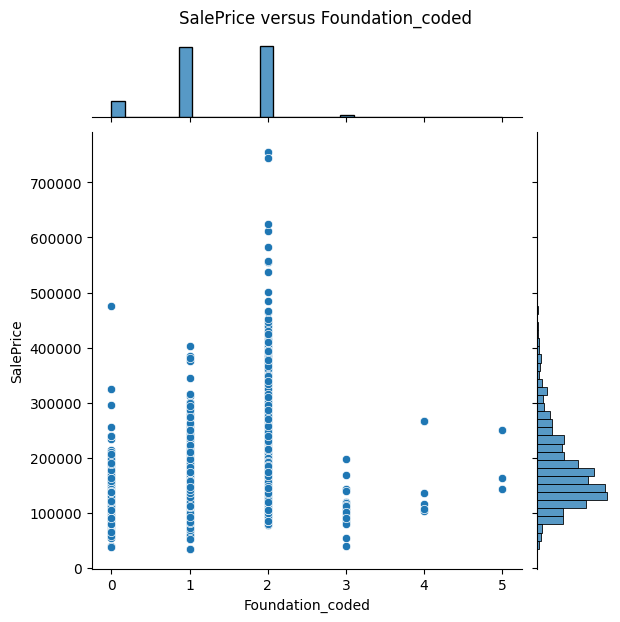

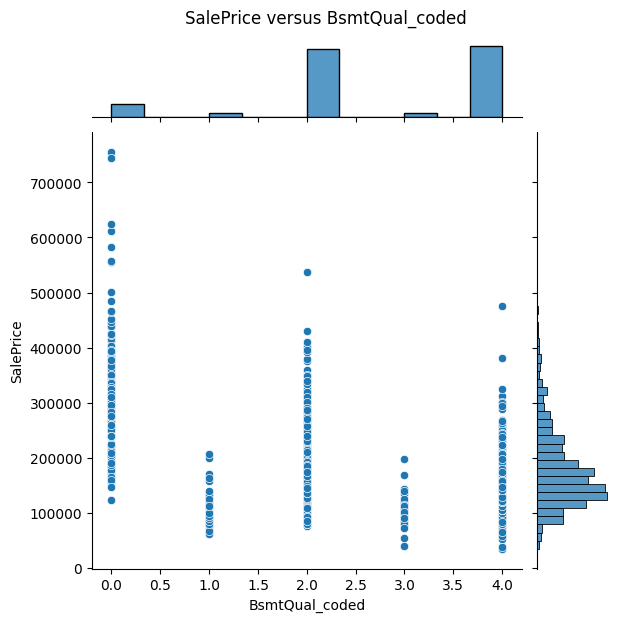

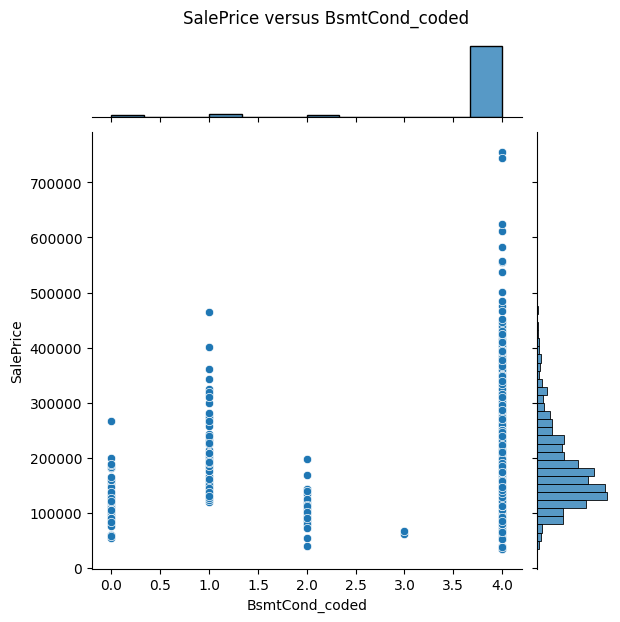

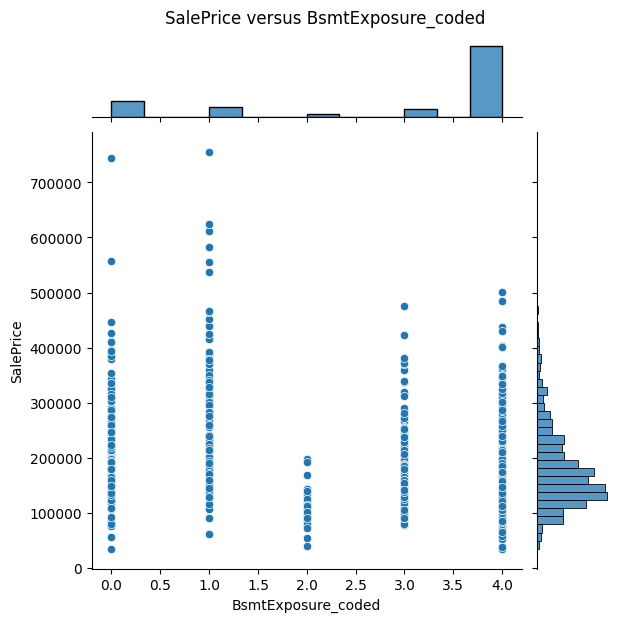

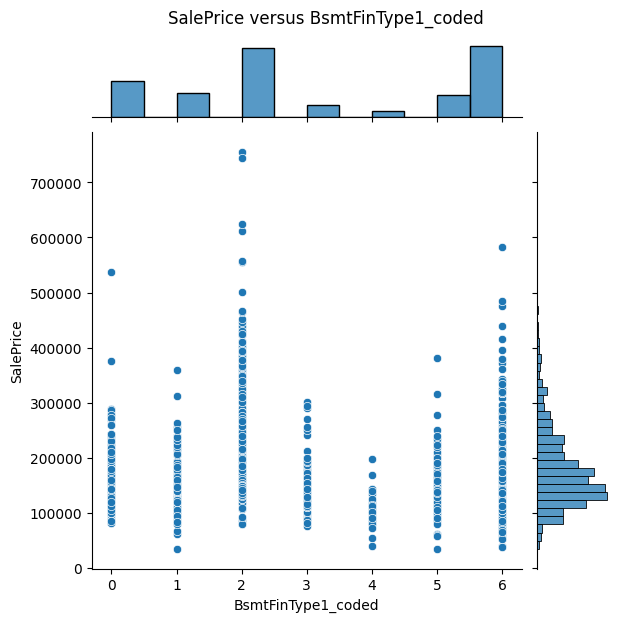

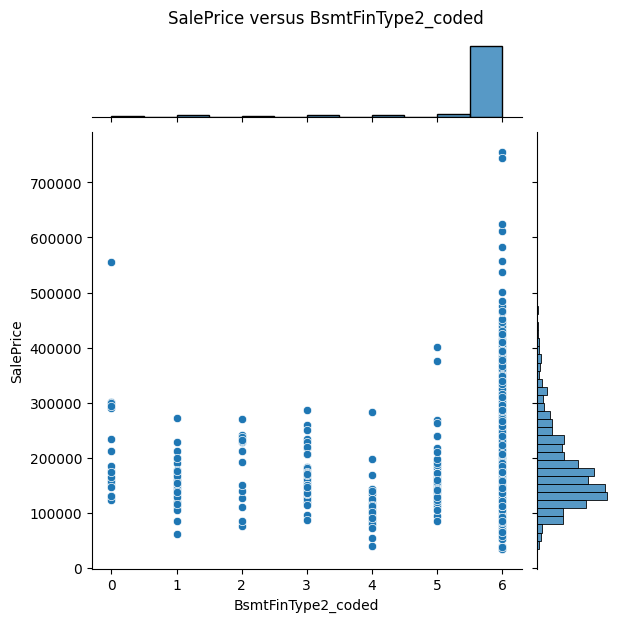

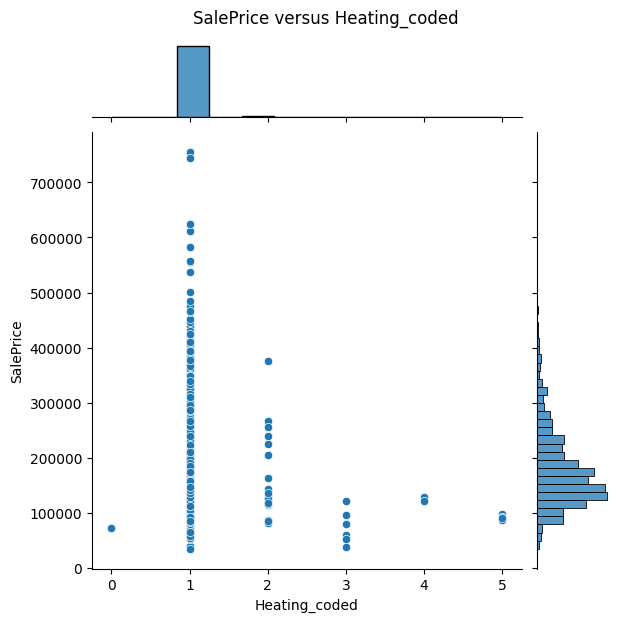

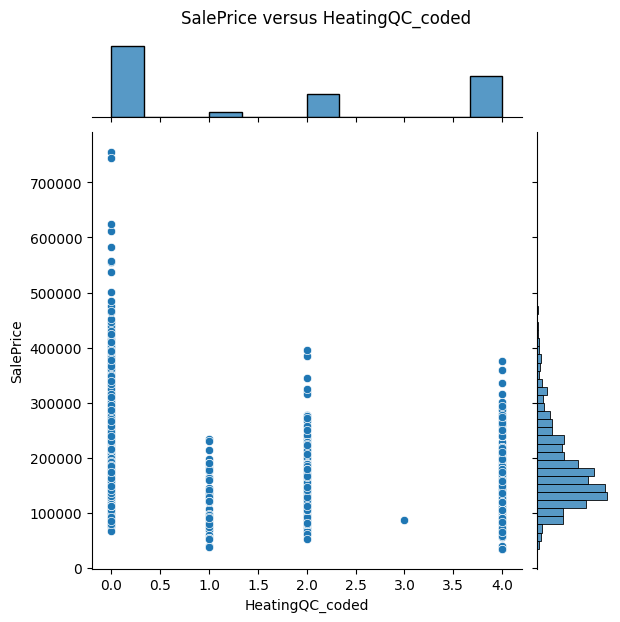

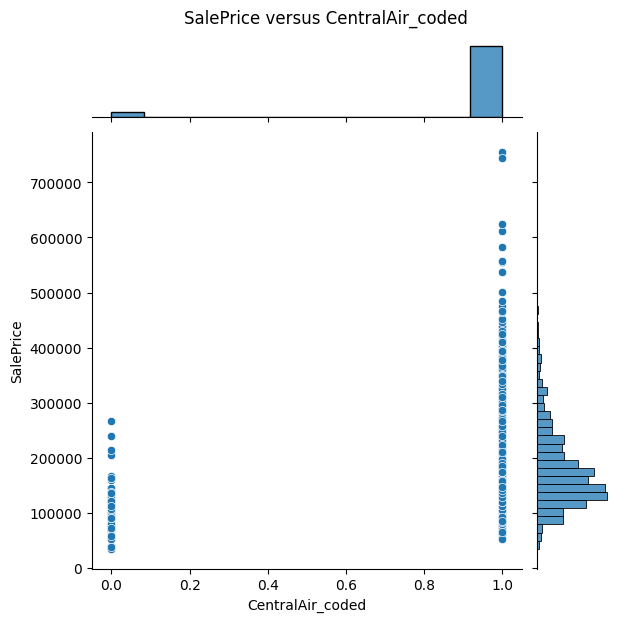

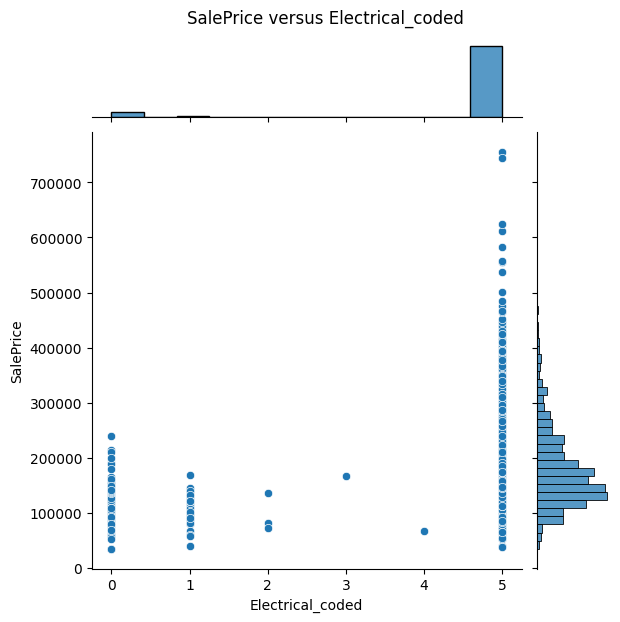

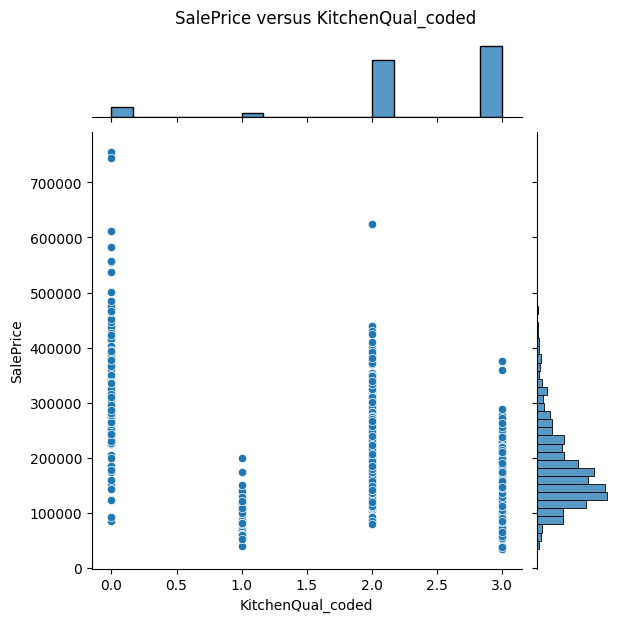

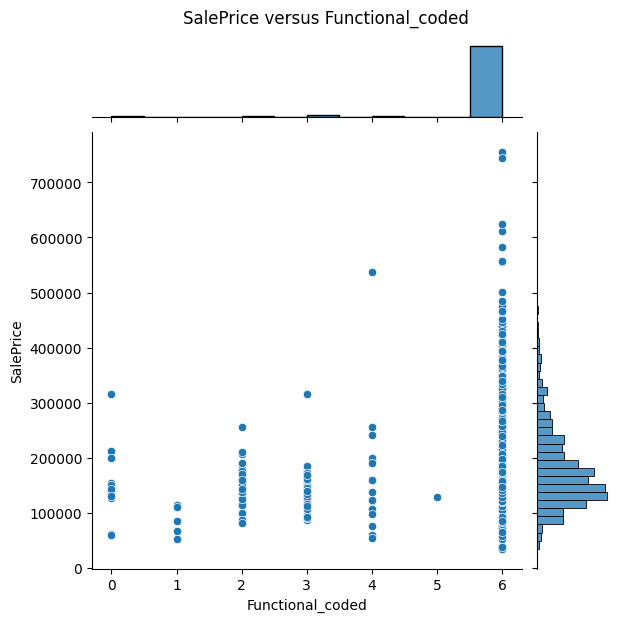

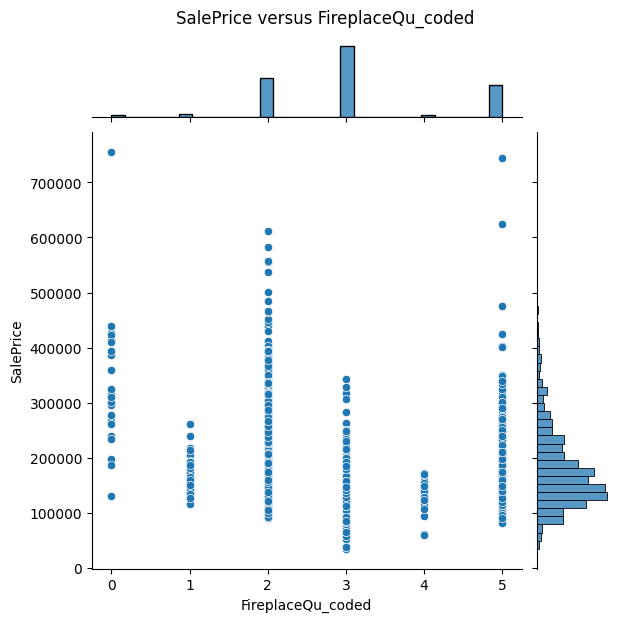

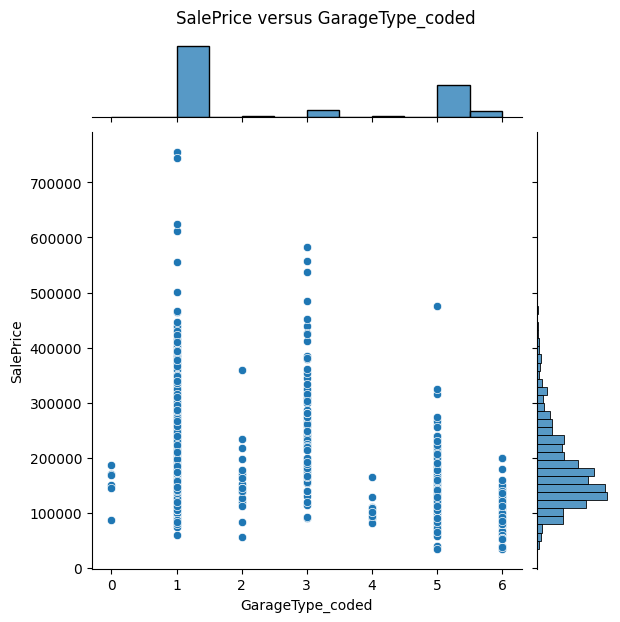

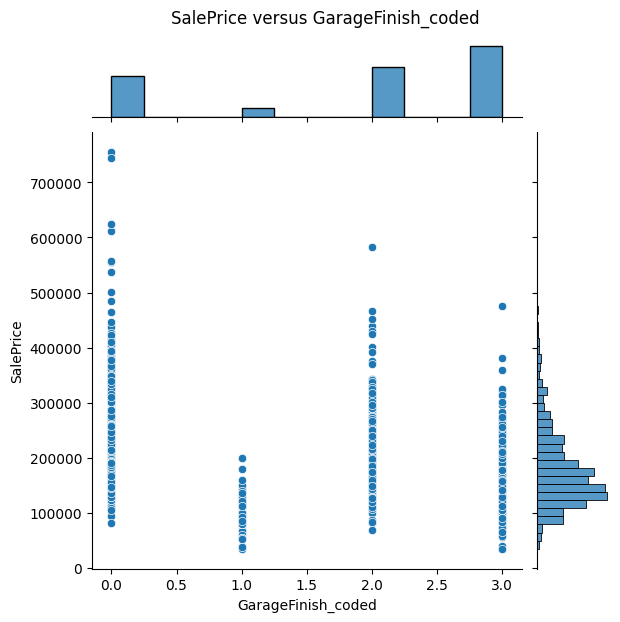

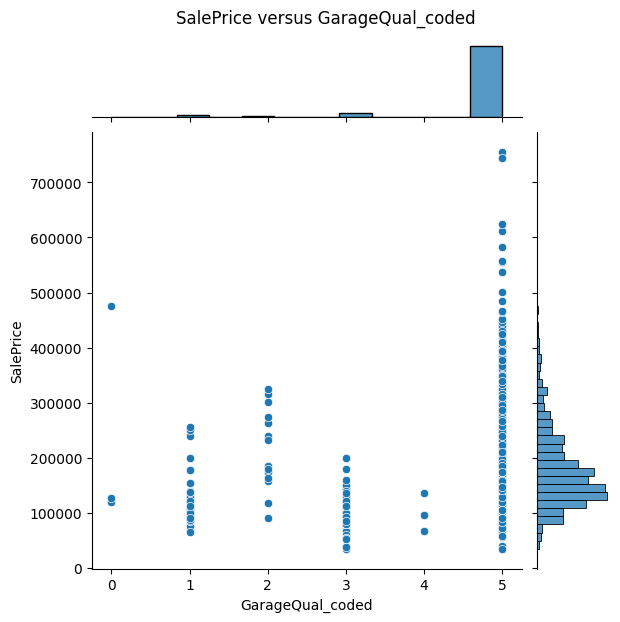

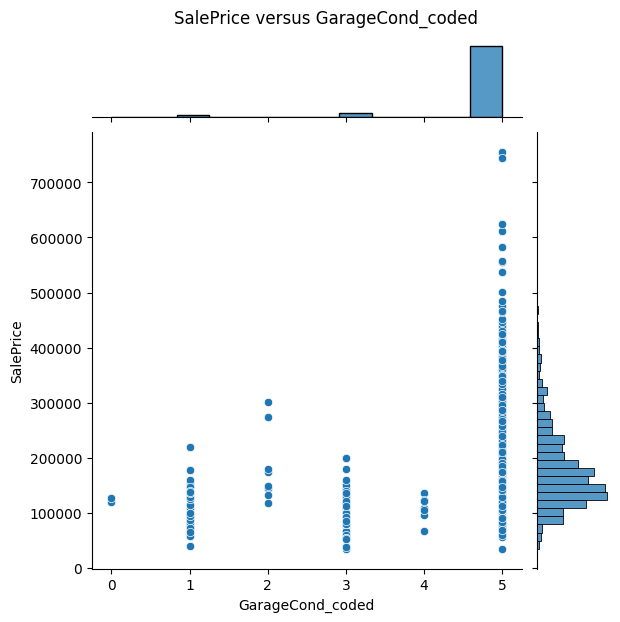

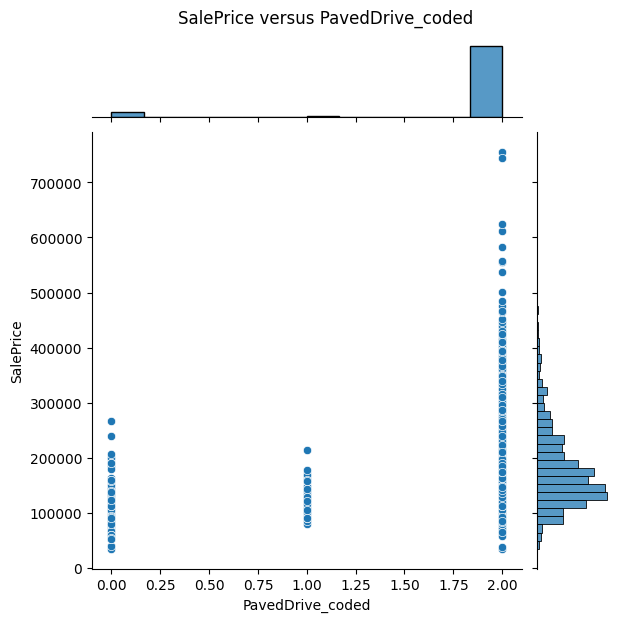

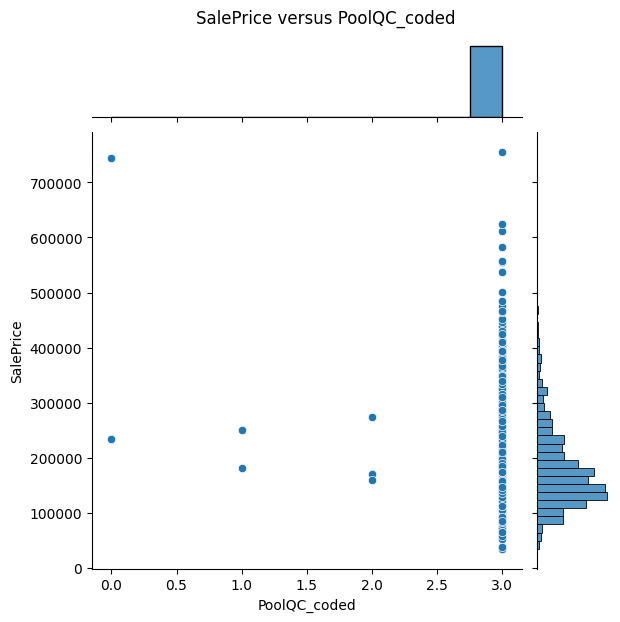

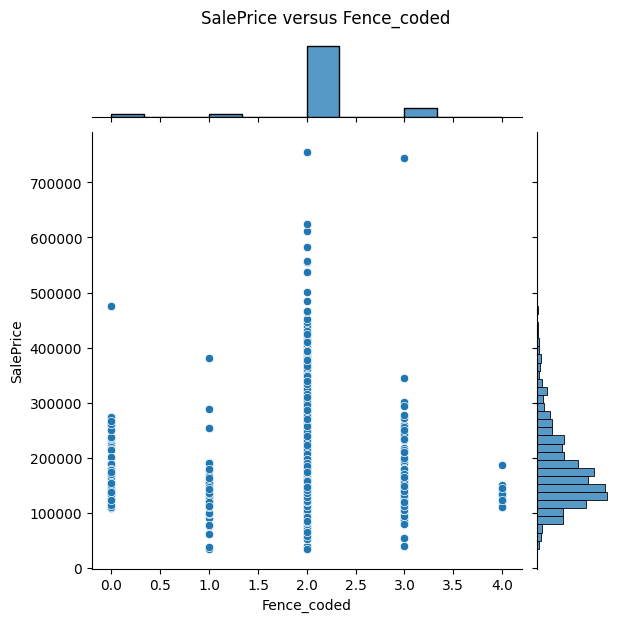

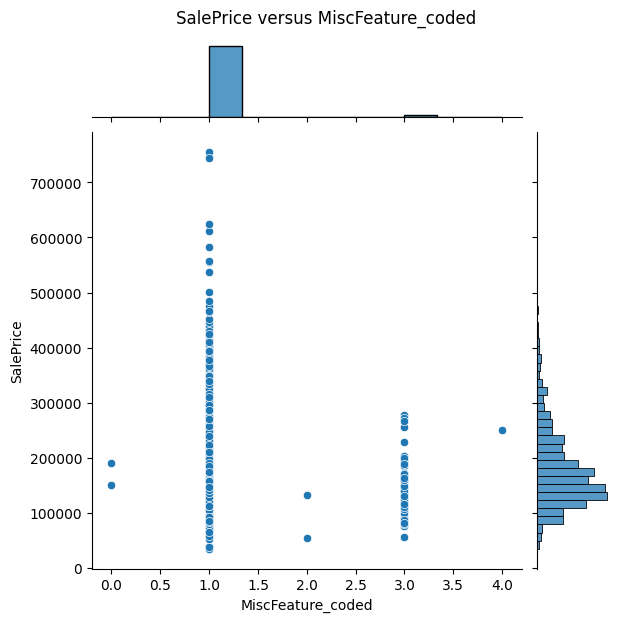

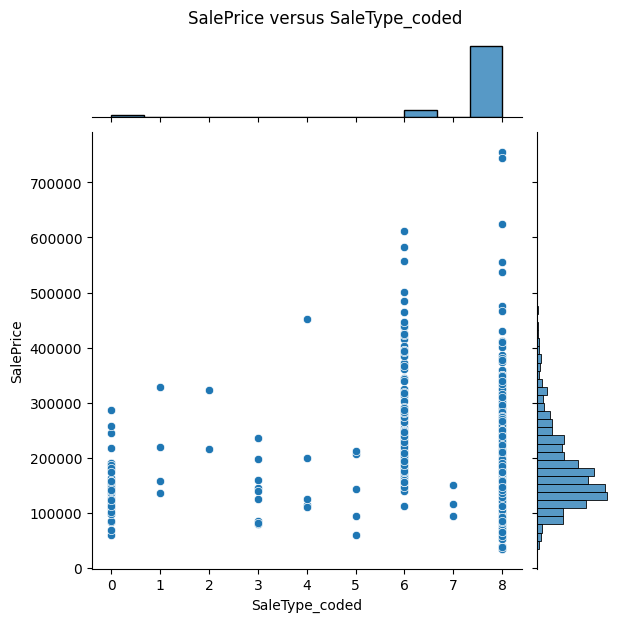

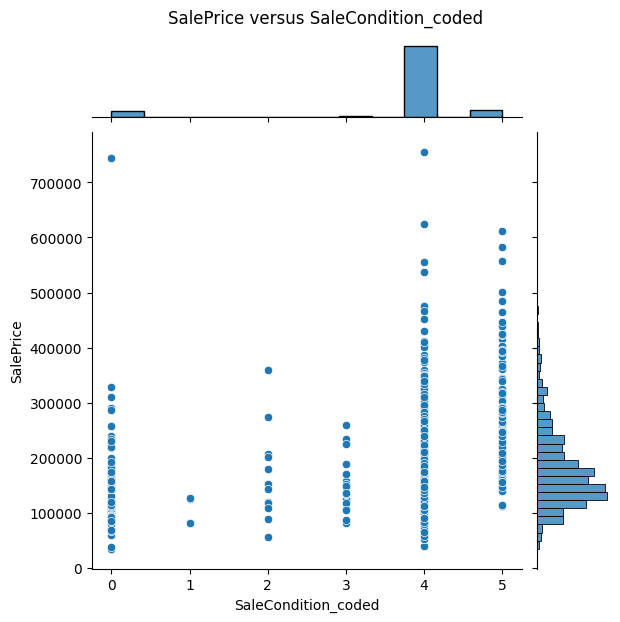

In [6]:
# individual plots i.e., sales price vs feature
feature_list = [col for col in train_df_coded.columns if col not in ["SalePrice", "Id"]]

for col in feature_list:
    g = sns.jointplot(data=train_df_coded, x=col, y="SalePrice")
    g.fig.suptitle(f"SalePrice versus {col}", y=1.03)
    plt.show()


Summary statistics of Sales price:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


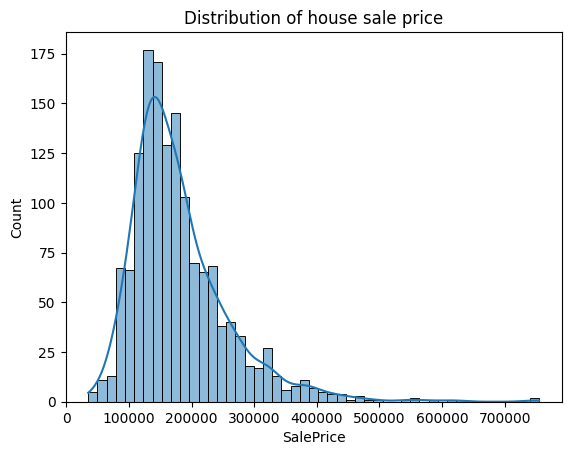

In [7]:
#Vizualizing and understanding the target

sns.histplot(data=train_df, x="SalePrice", kde=True)
plt.title("Distribution of house sale price")

print("\nSummary statistics of Sales price:")
print(train_df["SalePrice"].describe())


In [8]:
# Identifying outliers in each feature

data_for_outliers = train_df[integer_columns].copy()

outliers_index_df = pd.DataFrame()

for i in data_for_outliers.columns:
    Q1 = data_for_outliers[i].quantile(0.25)
    Q3 = data_for_outliers[i].quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5
    
    x = train_df[(data_for_outliers[i] < Q1 - threshold * IQR) | (data_for_outliers[i] > Q3 + threshold * IQR)]
    outliers_index_df [i] = pd.Series(x.index)

print("\nThe number of outliers identified in each column:\n")
print(outliers_index_df.count())



The number of outliers identified in each column:

MSSubClass       103
LotFrontage       16
LotArea           69
OverallQual        2
OverallCond      103
YearBuilt          7
YearRemodAdd       0
MasVnrArea        98
BsmtFinSF1         7
BsmtFinSF2       103
BsmtUnfSF         29
TotalBsmtSF       61
1stFlrSF          20
2ndFlrSF           2
LowQualFinSF      26
GrLivArea         31
BsmtFullBath       1
BsmtHalfBath      82
FullBath           0
HalfBath           0
BedroomAbvGr      35
KitchenAbvGr      68
TotRmsAbvGrd      30
Fireplaces         5
GarageYrBlt       81
GarageCars         5
GarageArea        21
WoodDeckSF        32
OpenPorchSF       77
EnclosedPorch    103
3SsnPorch         24
ScreenPorch      103
PoolArea           7
MiscVal           52
MoSold             0
YrSold             0
SalePrice         61
dtype: int64


In [9]:
# Onehotencoding for categorical columns and scalarizing integer columns
train_df_categorical = train_df[categorical_columns].copy()

train_df_int = train_df[integer_columns_without_target].copy()

scaler = StandardScaler()

onehot_encoder = OneHotEncoder(sparse=False, drop='first')

scaled_data = scaler.fit_transform(train_df_int)

onehot_encoded_data = onehot_encoder.fit_transform(train_df_categorical)

train_df_scalarized = pd.DataFrame(scaled_data, columns=scaler.get_feature_names_out(integer_columns_without_target))

train_df_categorical_onehot_encoded = pd.DataFrame(onehot_encoded_data, columns=onehot_encoder.get_feature_names_out(categorical_columns))

train_df_onehot_encoded_scalarized = pd.concat([train_df_scalarized, train_df_categorical_onehot_encoded], axis=1)

train_df_onehot_encoded = pd.concat([train_df_int, train_df_categorical_onehot_encoded], axis=1)


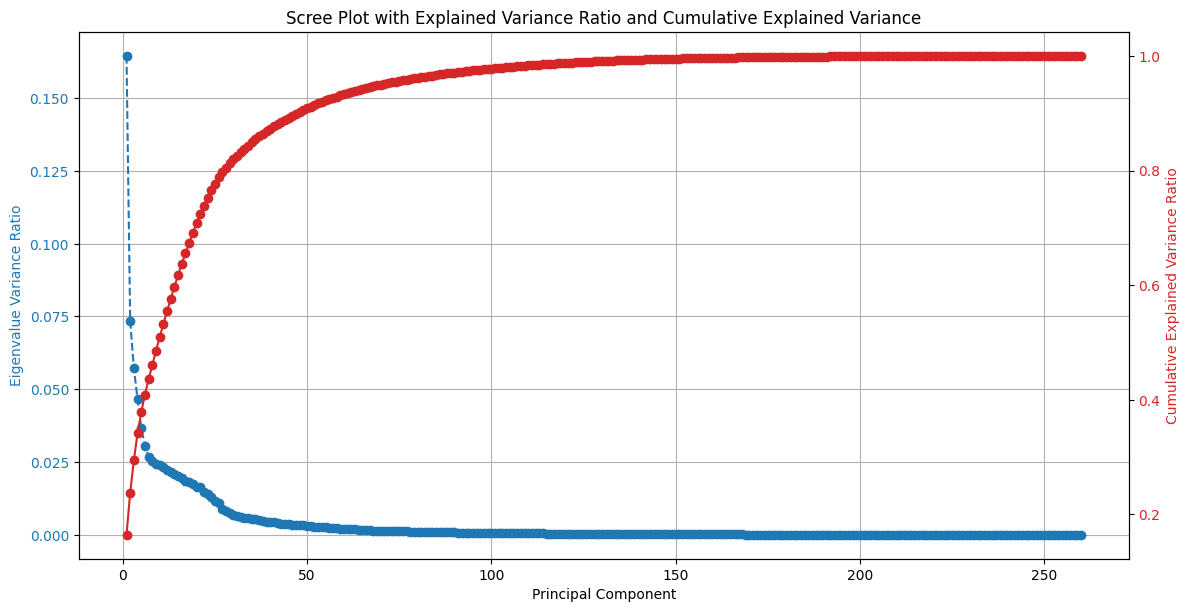

'\nThe highest eigen value ratio is 15% suggesting that there are no strong underlying patters in the input feature.\nFeature data is spread out and possibly complex.\n'

In [10]:
# Principal component analysis (PCA)
pca = PCA()

pca.fit_transform(train_df_onehot_encoded_scalarized)

explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue Variance Ratio', color=color)
ax1.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color=color, label='Explained Variance Ratio')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Cumulative Explained Variance Ratio', color=color)
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color=color, label='Cumulative Explained Variance Ratio')
ax2.tick_params(axis='y', labelcolor=color)

ax1.grid(True)
fig.tight_layout()
plt.title('Scree Plot with Explained Variance Ratio and Cumulative Explained Variance')

plt.show()

'''
The highest eigen value ratio is 15% suggesting that there are no strong underlying patters in the input feature.
Feature data is spread out and possibly complex.
'''

In [11]:
#Reloading training data as Onehot encoding is not needed for catboost
train_df = pd.read_csv(r"/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

for column in train_df.columns:
    if train_df[column].dtype == float or train_df[column].dtype == int:
        train_df[column] = train_df[column].fillna(0)
        
train_df[train_df.select_dtypes(include='float').columns] = train_df.select_dtypes(include='float').round().astype(int)

categorical_columns = [col for col in train_df.columns if train_df[col].dtype == object]

integer_columns = [col for col in train_df.columns if train_df[col].dtype != object]

integer_columns.remove("Id")

integer_columns_without_target = [col for col in integer_columns if col != "SalePrice"]

train_df[categorical_columns] = train_df[categorical_columns].fillna('Missing')

#Training a preliminary catboost model

X = train_df.drop(columns=["SalePrice", "Id"]).copy()

y = np.log1p(train_df["SalePrice"].copy())

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

prelim_catboost_regressor = CatBoostRegressor(iterations = 1000,
                                               learning_rate = 0.01,
                                               depth = 4,
                                               l2_leaf_reg = 2,
                                               cat_features = categorical_columns,
                                               loss_function = "RMSE",
                                               silent = True)

prelim_catboost_regressor.fit(X_train, y_train)

train_R2 = prelim_catboost_regressor.score(X_train,y_train)

val_R2 = prelim_catboost_regressor.score(X_val,y_val)

print(f"\nInitial model training R_square: {train_R2}")

print(f"\nInitial model validation R_square: {val_R2}")


Initial model training R_square: 0.9311934831660942

Initial model validation R_square: 0.905942185664268


In [12]:
# Feature importance

feature_importance = prelim_catboost_regressor.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature importance:")
print(importance_df.to_string())


Feature importance:
          Feature  Importance
45      GrLivArea   18.156127
16    OverallQual   17.220246
26      ExterQual    5.047511
37    TotalBsmtSF    4.497573
60     GarageCars    3.571653
42       1stFlrSF    3.489843
3         LotArea    3.455236
18      YearBuilt    3.392709
59   GarageFinish    3.130648
29       BsmtQual    2.928880
57     GarageType    2.921080
52    KitchenQual    2.699693
33     BsmtFinSF1    2.649616
55     Fireplaces    2.404379
17    OverallCond    2.238532
56    FireplaceQu    2.008469
11   Neighborhood    1.902102
61     GarageArea    1.872505
40     CentralAir    1.651851
19   YearRemodAdd    1.351341
43       2ndFlrSF    1.217497
58    GarageYrBlt    1.032980
62     GarageQual    0.970576
1        MSZoning    0.794744
48       FullBath    0.712789
46   BsmtFullBath    0.677480
53   TotRmsAbvGrd    0.581926
64     PavedDrive    0.561804
39      HeatingQC    0.532755
30       BsmtCond    0.473312
31   BsmtExposure    0.458472
78  SaleCondition  

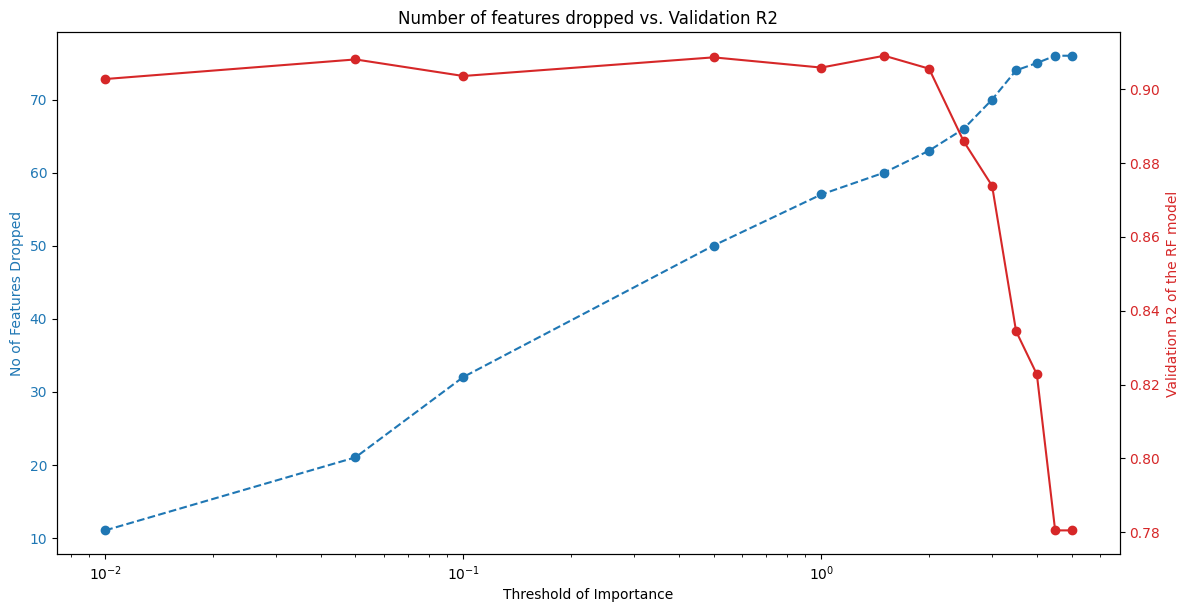

In [13]:
'''
Identifying ideal threshold/s to drop features below an importance value and retraining the model
'''

Feature_selection_df = pd.DataFrame(columns = ["Threshold", "No_of_features_dropped", "R2"])

Feature_selection_df = Feature_selection_df.astype({"Threshold": "float", "No_of_features_dropped": "int", "R2": "float"})

threshold_values = [0.01, 0.05, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]

Feature_selection_df["Threshold"] = threshold_values

for threshold in threshold_values:
    
    features_with_low_importance = [col for col in importance_df["Feature"] if importance_df.loc[importance_df["Feature"] == col, "Importance"].values[0] <= threshold]
    
    Feature_selection_df.loc[Feature_selection_df["Threshold"]==threshold,"No_of_features_dropped"] = len(features_with_low_importance)

    # Fitting a model after dropping features
    
    X_modified = X_temp.copy()
    
    y_modified = y_temp.copy()
    
    X_modified.drop(columns = features_with_low_importance, inplace = True)
    
    modified_categorical_columns = [col for col in X_modified.columns if X_modified[col].dtype == object]
    
    X_modified_train, X_modified_val, y_modified_train, y_modified_val = train_test_split(X_modified, y_modified, test_size=0.15, random_state=42)
    
    modified_catboost_regressor = CatBoostRegressor(iterations = 1000,
                                                   learning_rate = 0.01,
                                                   depth = 4,
                                                   l2_leaf_reg = 2,
                                                   cat_features = modified_categorical_columns,
                                                   loss_function = "RMSE",
                                                   silent = True)
    
    modified_catboost_regressor.fit(X_modified_train, y_modified_train)
    
    Feature_selection_df.loc[Feature_selection_df["Threshold"]==threshold,"R2"] = modified_catboost_regressor.score(X_modified_val,y_modified_val)

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Threshold of Importance')
ax1.set_ylabel('No of Features Dropped', color=color)
ax1.plot(Feature_selection_df["Threshold"], Feature_selection_df["No_of_features_dropped"], marker='o', linestyle='--', color=color, label='Number of features dropped')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Validation R2 of the RF model', color=color)
ax2.plot(Feature_selection_df["Threshold"], Feature_selection_df["R2"], marker='o', linestyle='-', color=color, label='R2')
ax2.tick_params(axis='y', labelcolor=color)

plt.xscale('log')
fig.tight_layout()
plt.title('Number of features dropped vs. Validation R2')

plt.show()

In [14]:
'''
Based on the threshold vs. validation R² plot, a threshold of 0.5 yields good performance without dropping too many predictors
and is therefore selected.
'''
# Hyperparameter tuning

features_dropped_from_model = [col for col in importance_df["Feature"] if importance_df.loc[importance_df["Feature"] == col, "Importance"].values[0] <= 0.5]

print("\nNumber of features dropped: {}".format(len(features_dropped_from_model)))

X_modified = X_temp.copy()

y_modified = y_temp.copy()

X_modified.drop(columns = features_dropped_from_model, inplace = True)

modified_categorical_columns = [col for col in X_modified.columns if X_modified[col].dtype == object]

X_modified_train, X_modified_val, y_modified_train, y_modified_val = train_test_split(X_modified, y_modified, test_size=0.15, random_state=42)

model = CatBoostRegressor(cat_features = modified_categorical_columns, silent = True)

param_grid = {'iterations': randint(300, 1000),
                'depth': randint(3, 6),
                'learning_rate': uniform(0.01, 0.1),
                'l2_leaf_reg': randint(1, 6),
                'bagging_temperature': uniform(0.2, 0.7),  # stochasticity
                'border_count': randint(32, 64),  # for numerical features
                'random_strength': uniform(1, 10),  # split score noise
                'grow_policy': ['SymmetricTree'],
                'bootstrap_type': ['Bayesian'],
                'loss_function': ['RMSE']}

random_search = RandomizedSearchCV(estimator=model,
                                    param_distributions=param_grid,  
                                    n_iter=50,                       
                                    cv=5,
                                    scoring='r2',
                                    verbose=1,
                                    random_state=42,
                                    n_jobs= -1)

random_search.fit(X_modified_train, y_modified_train)

best_params = random_search.best_params_

print("\nBest Parameters:", best_params)

optimized_catboost_model = CatBoostRegressor(**best_params,
                                             early_stopping_rounds=7,
                                             cat_features=modified_categorical_columns,
                                             silent = True)

optimized_catboost_model.fit(X_modified_train, y_modified_train,
                        eval_set=[(X_modified_val, y_modified_val)],
                        verbose = False)

X_test_selected = X_test[X_modified.columns]

Training_R2 = optimized_catboost_model.score(X_modified_train, y_modified_train)
Final_R2 = optimized_catboost_model.score(X_test_selected, y_test)

print("\nBelow are the features in the final model:")
for feature in X_modified.columns:
    print("\n" + feature)

print(f"\nFinal model training accuracy (R_square): {Training_R2}")
print(f"\nFinal model test accuracy (R_square): {Final_R2}")


Number of features dropped: 50
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'bagging_temperature': 0.3708878655734419, 'bootstrap_type': 'Bayesian', 'border_count': 58, 'depth': 4, 'grow_policy': 'SymmetricTree', 'iterations': 971, 'l2_leaf_reg': 1, 'learning_rate': 0.050383617105804086, 'loss_function': 'RMSE', 'random_strength': 1.6489224710898156}

Below are the features in the final model:

MSZoning

LotArea

Neighborhood

OverallQual

OverallCond

YearBuilt

YearRemodAdd

ExterQual

BsmtQual

BsmtFinSF1

TotalBsmtSF

HeatingQC

CentralAir

1stFlrSF

2ndFlrSF

GrLivArea

BsmtFullBath

FullBath

KitchenQual

TotRmsAbvGrd

Fireplaces

FireplaceQu

GarageType

GarageYrBlt

GarageFinish

GarageCars

GarageArea

GarageQual

PavedDrive

Final model training accuracy (R_square): 0.9450153633307985

Final model test accuracy (R_square): 0.9203644278876497


In [15]:
'''
Final submission of test results to kaggle
'''
test_df = pd.read_csv(r"/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

for column in test_df.columns:
    if test_df[column].dtype == float or test_df[column].dtype == int:
        test_df[column] = test_df[column].fillna(0)
        
test_df[test_df.select_dtypes(include='float').columns] = test_df.select_dtypes(include='float').round().astype(int)

test_df[categorical_columns] = test_df[categorical_columns].fillna('Missing')

log_preds = optimized_catboost_model.predict(test_df[X_modified.columns])

y_pred = np.expm1(log_preds)

submission = pd.DataFrame(columns = ['Id', 'SalePrice'])

submission['Id'] = test_df['Id']
submission['SalePrice'] = y_pred
print("\nBelow are the predictions on the unlabeled test data:")
print(submission)
submission.to_csv('submission.csv', index=False)


Below are the predictions on the unlabeled test data:
        Id      SalePrice
0     1461  125293.629216
1     1462  148055.457956
2     1463  178924.336578
3     1464  181529.838415
4     1465  183513.800339
...    ...            ...
1454  2915   85293.276288
1455  2916   92350.291381
1456  2917  166884.046926
1457  2918  120446.593661
1458  2919  214883.219158

[1459 rows x 2 columns]
